In [2]:
import pandas as pd
import numpy as np
from joblib import Parallel, delayed
from contextlib import contextmanager
import joblib
from tqdm import tqdm
import os
import pathlib
import pickle as pkl
tqdm.pandas()

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
from matplotlib.patches import Ellipse, Circle
import seaborn as sns

from scipy.stats import ttest_rel, ttest_ind, mannwhitneyu, wilcoxon, binomtest, ttest_1samp

pd.set_option('display.max_rows', 500)

from IPython.display import HTML

In [3]:
def do_btest(strat):
    # Lets now do the binomial tests for the strategy against a1 and a2
    btest = []
    for i in range(len(strat)):
        n = strat.iloc[i].a1 + strat.iloc[i].a2
        btest.append(binomtest(strat.iloc[i].a1, n, 0.5, alternative="two-sided").pvalue)
    return np.array(btest)

In [4]:
np.random.seed(0)
leader_index = np.random.choice(np.arange(200), 100, replace=False)
leader_index = np.sort(leader_index)
follower_index = np.array([i for i in range(200) if i not in leader_index])


## Testing

In [54]:

base= "../store_bk"
trains = sorted(os.listdir(base))

strat_1 = []
strat_2 = []
strat_3 = []

train_tt = []

for i in tqdm(trains[:]):
    f = f"{base}/{i}/trial_stats/testing_1.parquet"
    t = pd.read_parquet(f)
    train_tt.append(t.trial_id.max())
    strat_1.append(t.activated_by.value_counts().to_dict())
    strat_2.append(t.first_close_to_zone.value_counts().to_dict())
    strat_3.append(t.first_to_zone.value_counts().to_dict())

100%|██████████| 200/200 [00:04<00:00, 47.64it/s]


In [5]:
l1 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_1]
f1 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_1]

l2 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_2]
f2 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_2]

l3 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_3]
f3 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_3]

# renamed mouse list
mst1 = []
mst2 = []
mst3 = []

for i in leader_index:
    mst1.append({ "a1": strat_1[i][l1[i]], "a2": strat_1[i][f1[i]] })
    mst2.append({ "a1": strat_2[i][l1[i]], "a2": strat_2[i][f1[i]] })
    mst3.append({ "a1": strat_3[i][l1[i]], "a2": strat_3[i][f1[i]] })
for j in follower_index:
    mst1.append({ "a1": strat_1[j][f1[j]], "a2": strat_1[j][l1[j]] })
    mst2.append({ "a1": strat_2[j][f1[j]], "a2": strat_2[j][l1[j]] })
    mst3.append({ "a1": strat_3[j][f1[j]], "a2": strat_3[j][l1[j]] })
    
strat_1 = mst1
strat_2 = mst2
strat_3 = mst3

In [6]:
len(strat_1), len(strat_2), len(strat_3)

(200, 200, 200)

In [55]:
test_strats = (strat_1, strat_2, strat_3)

cols = ["a1", "a2", "tie"]
strat_1 = pd.DataFrame(strat_1, columns=cols)
strat_2 = pd.DataFrame(strat_2, columns=cols)
strat_3 = pd.DataFrame(strat_3, columns=cols)

strat_1 = strat_1.fillna(0).astype(int)
strat_2 = strat_2.fillna(0).astype(int)
strat_3 = strat_3.fillna(0).astype(int)

s1_btest = pd.Series(do_btest(strat_1), name="pval")
s2_btest = pd.Series(do_btest(strat_2), name="pval")
s3_btest = pd.Series(do_btest(strat_3), name="pval")

l1 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_1.to_dict(orient="records")]
f1 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_1.to_dict(orient="records")]

l2 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_2.to_dict(orient="records")]
f2 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_2.to_dict(orient="records")]

l3 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_3.to_dict(orient="records")]
f3 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_3.to_dict(orient="records")]

test_sig = pd.DataFrame({
    "l1": [ strat_1.iloc[i][l1[i]] for i in range(len(l1))],
    "f1": [ strat_1.iloc[i][f1[i]] for i in range(len(f1))],
    "s1": s1_btest,
    "l2": [ strat_2.iloc[i][l2[i]] for i in range(len(l2))],
    "f2": [ strat_2.iloc[i][f2[i]] for i in range(len(f2))],
    "s2": s2_btest,
    "l3": [ strat_3.iloc[i][l3[i]] for i in range(len(l3))],
    "f3": [ strat_3.iloc[i][f3[i]] for i in range(len(f3))],
    "s3": s3_btest,
})

In [56]:
ns1 = strat_1[["a1", "a2"]] / strat_1[["a1", "a2"]].sum(axis=1).values[:, None]
ns2 = strat_2[["a1", "a2"]] / strat_2[["a1", "a2"]].sum(axis=1).values[:, None]
ns3 = strat_3[["a1", "a2"]] / strat_3[["a1", "a2"]].sum(axis=1).values[:, None]

In [57]:
titles = ["L1/F1 Strategy", "L2/F2 Strategy", "L3/F3 Strategy"]
mycols = sns.hls_palette(n_colors=3, h=0.01, l=0.6, s=0.65, as_cmap=False)


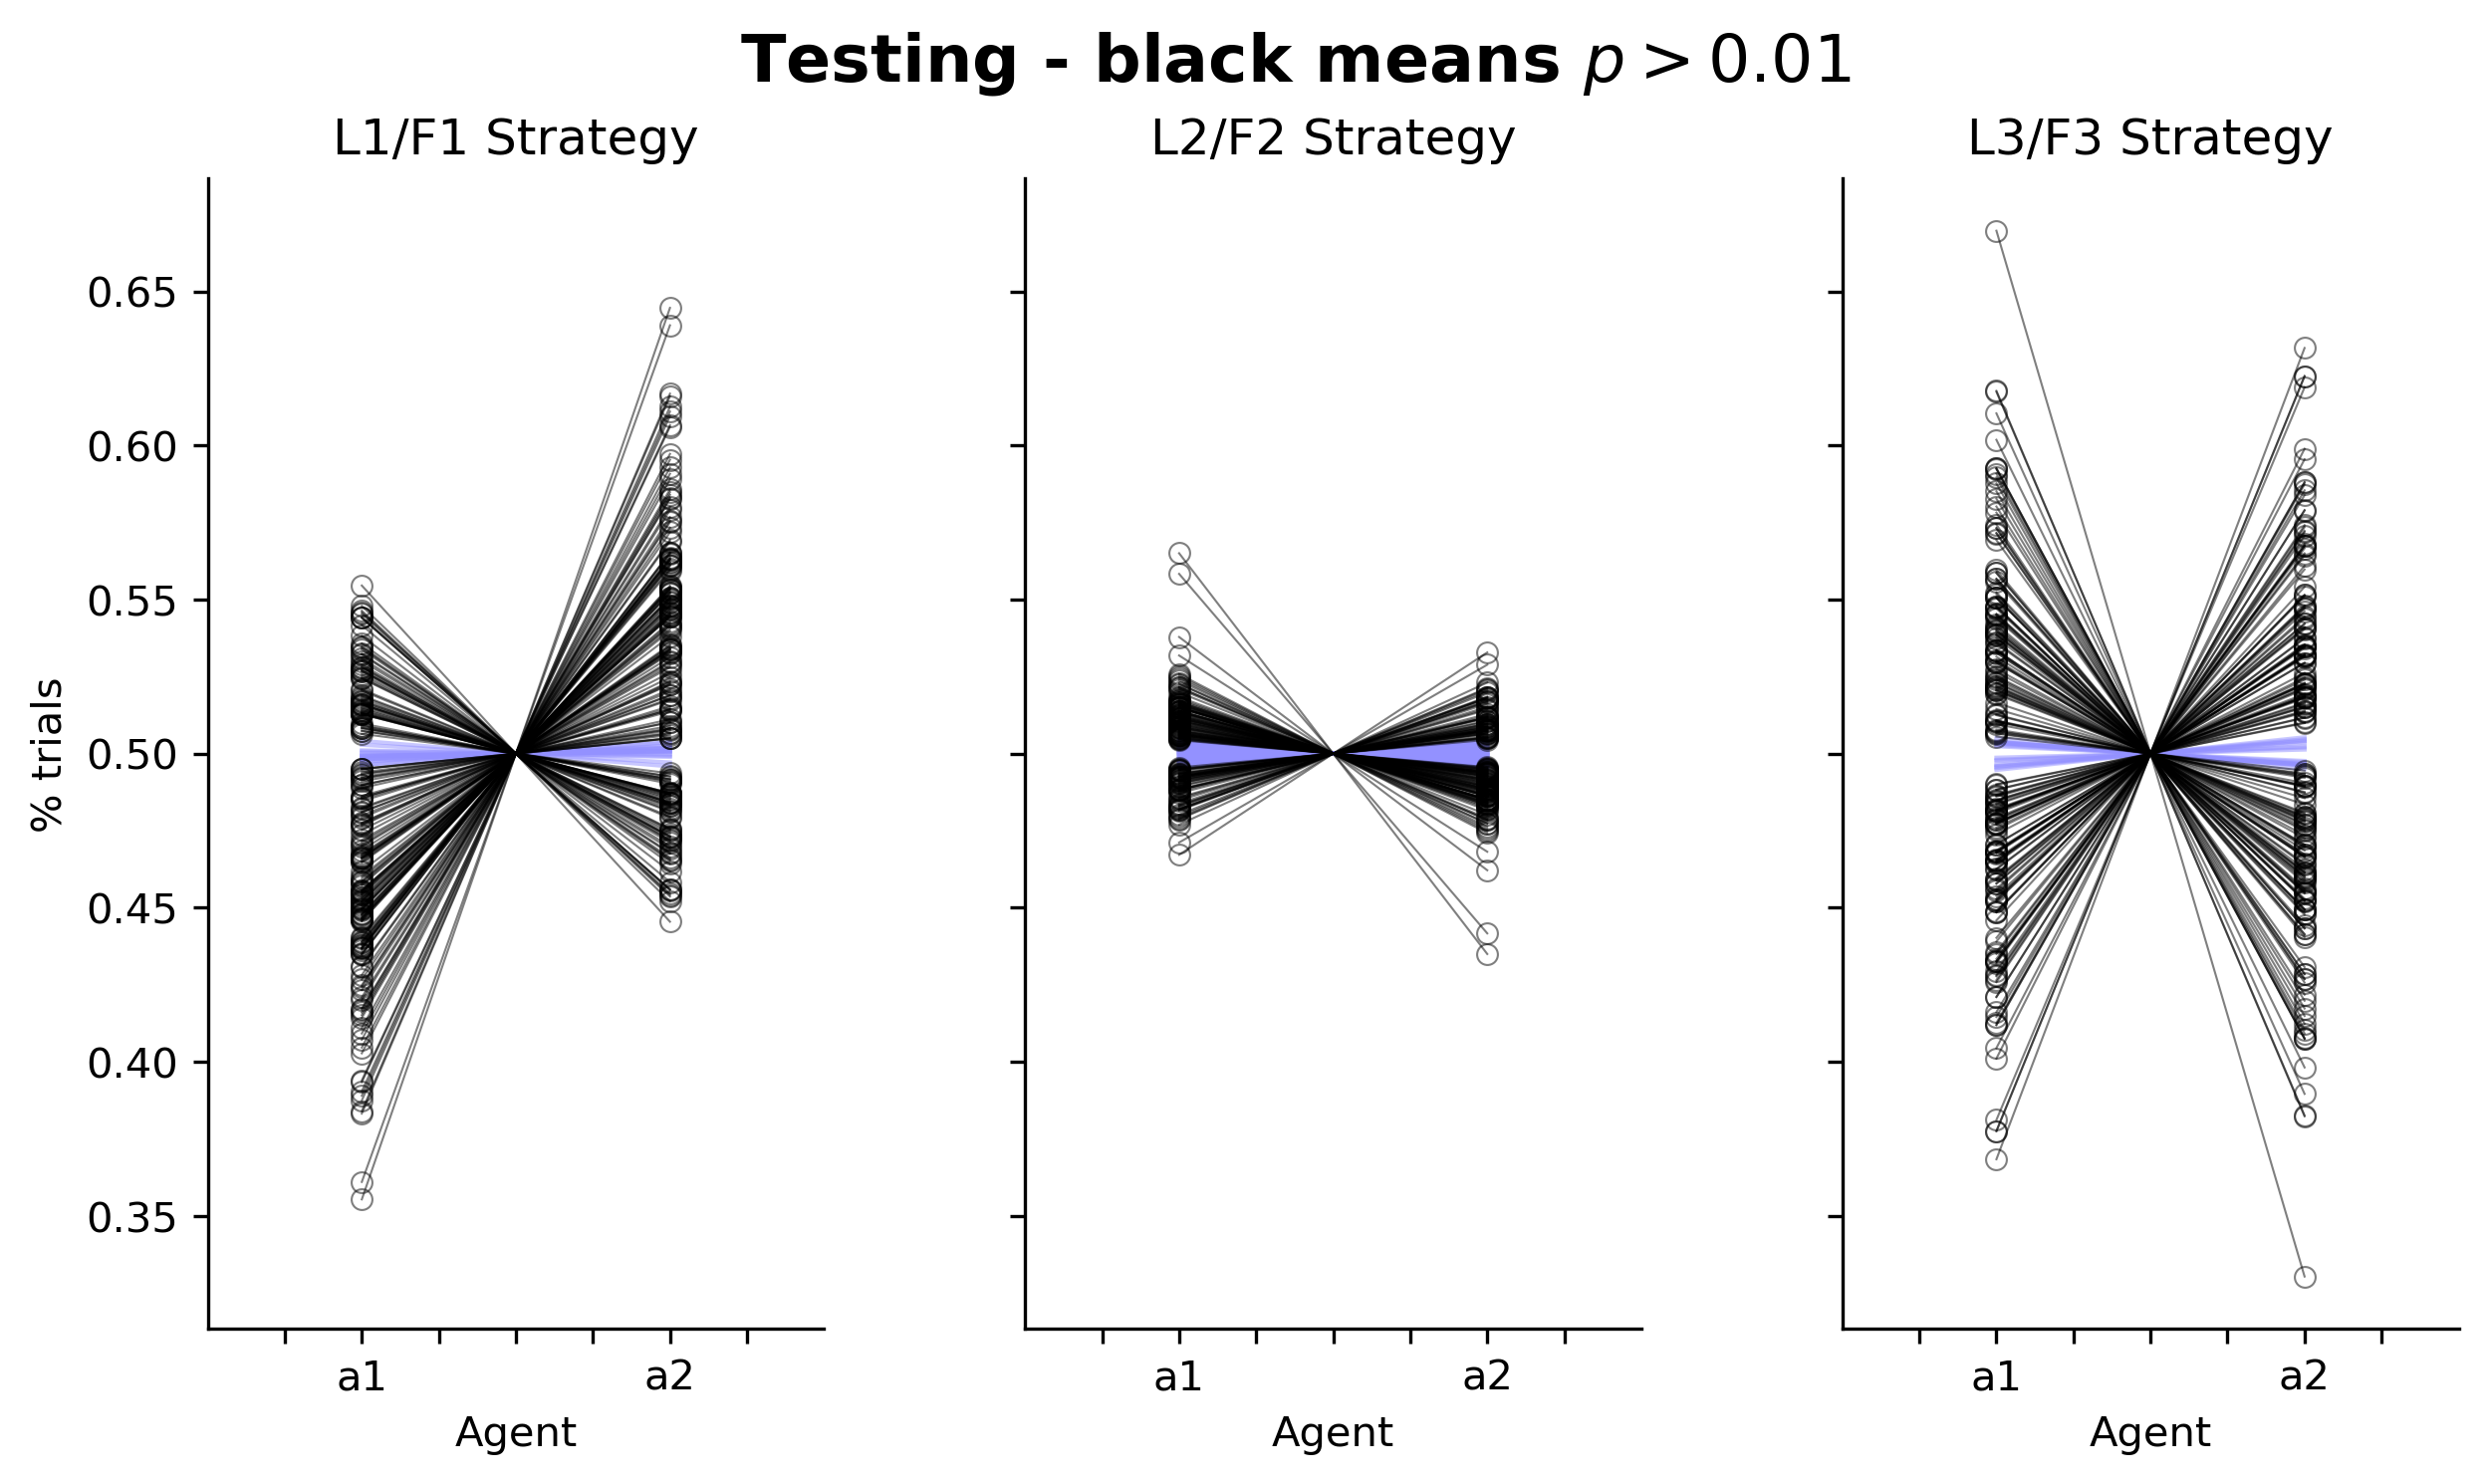

In [58]:
sig_color = "black"
insig_color = "#9391ff"
fig, ax = plt.subplots(1, 3, figsize=(10, 5), dpi=300, sharey=True)

for i in range(len(ns1)):
    if s1_btest[i] > 0.01:
        ns1.iloc[i].plot(ax=ax[0], color=insig_color, linewidth=1, alpha=0.5)
    
    if s2_btest[i] > 0.01:
        ns2.iloc[i].plot(ax=ax[1], color=insig_color, linewidth=1, alpha=0.5)
    
    if s3_btest[i] > 0.01:
        ns3.iloc[i].plot(ax=ax[2], color=insig_color, linewidth=1, alpha=0.5)

for i in range(len(ns1)):
    if s1_btest[i] < 0.01:
        ns1.iloc[i].plot(ax=ax[0], color=sig_color, linewidth=0.5, alpha=0.5, marker="o", markersize=5, markerfacecolor="none", markeredgewidth=0.5)
    
    if s2_btest[i] < 0.01:
        ns2.iloc[i].plot(ax=ax[1], color=sig_color, linewidth=0.5, alpha=0.5, marker="o", markersize=5, markerfacecolor="none", markeredgewidth=0.5)
    
    if s3_btest[i] < 0.01:
        ns3.iloc[i].plot(ax=ax[2], color=sig_color, linewidth=0.5, alpha=0.5, marker="o", markersize=5, markerfacecolor="none", markeredgewidth=0.5)


for i in range(3):
    ax[i].set_xlabel("Agent")
    ax[i].set_ylabel("% trials")
    ax[i].set_title(titles[i])
    ax[i].set_aspect(10)
    # remove top and right spines
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    
    ax[i].set_xlim(-0.5, 1.5)


plt.suptitle("Testing - black means $p>0.01$", fontsize=16, weight='bold')
# plt.tight_layout()
# plt.show()
plt.savefig("testing_proportions.svg", format="svg")

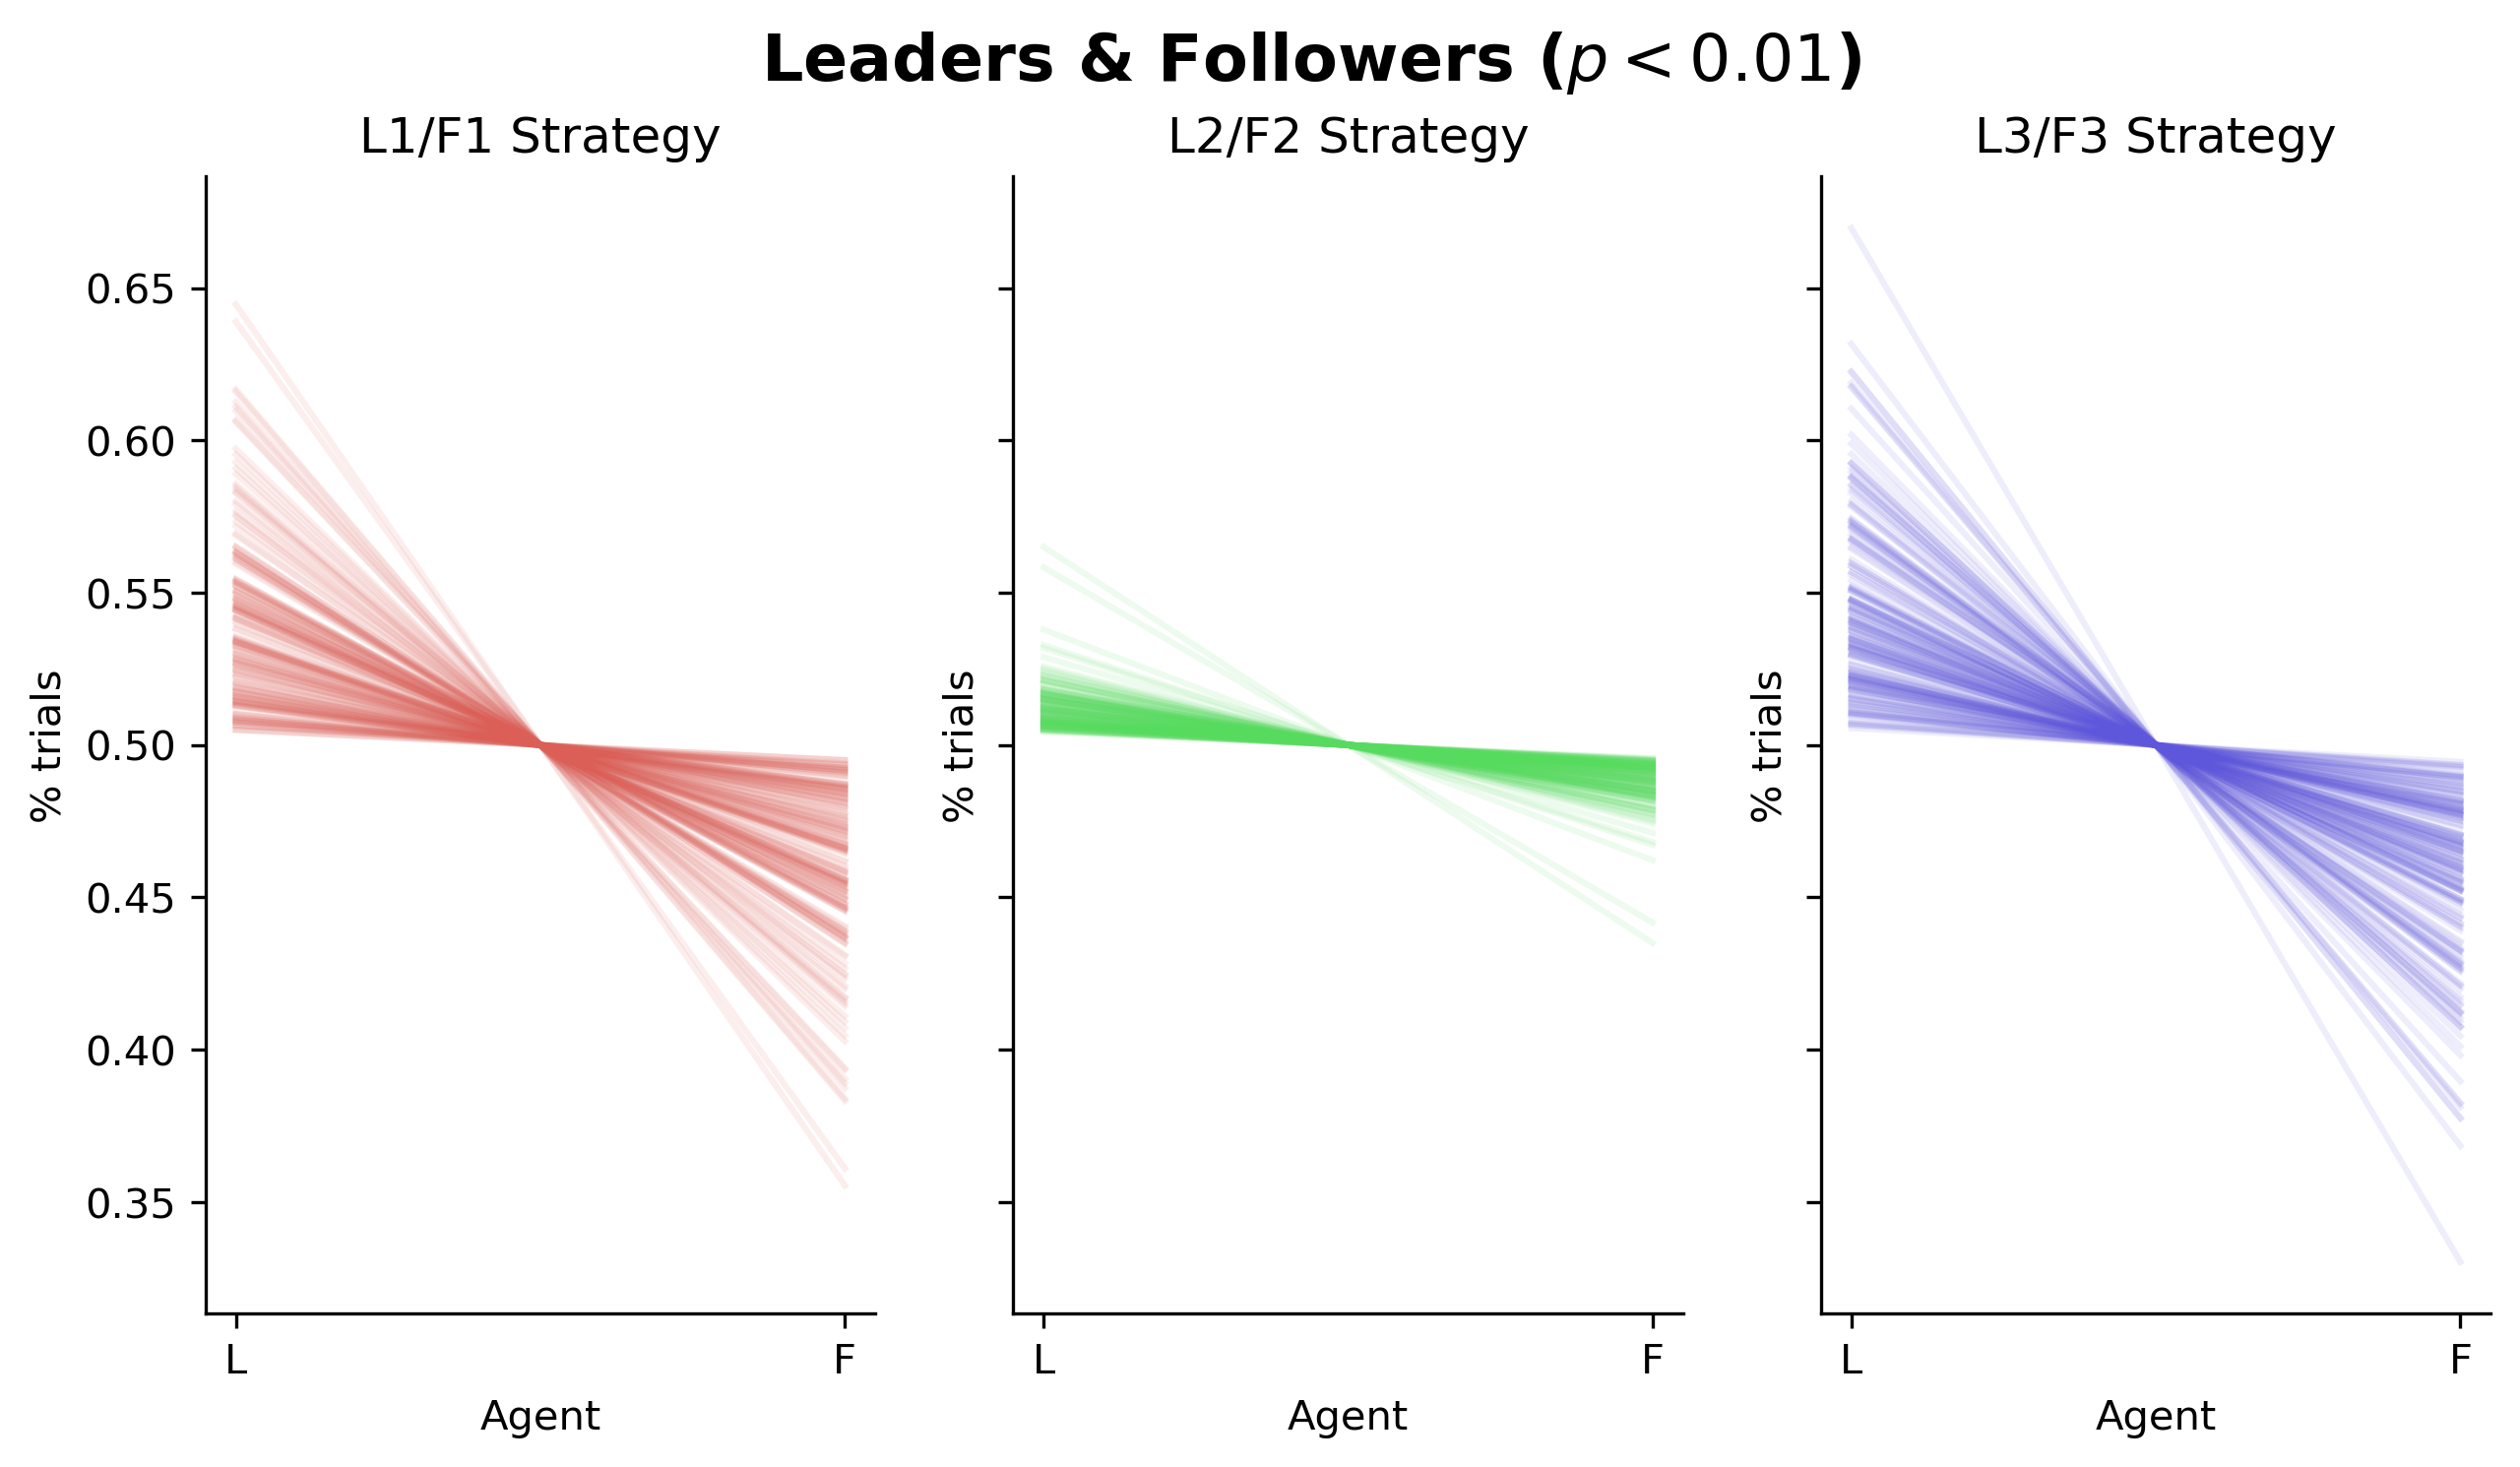

In [59]:

ns1 = strat_1[["a1", "a2"]] / strat_1[["a1", "a2"]].sum(axis=1).values[:, None]
ns2 = strat_2[["a1", "a2"]] / strat_2[["a1", "a2"]].sum(axis=1).values[:, None]
ns3 = strat_3[["a1", "a2"]] / strat_3[["a1", "a2"]].sum(axis=1).values[:, None]
insig_color = "black"
fig, ax = plt.subplots(1, 3, figsize=(10, 5), dpi=300, sharey=True)
for i in range(len(ns1)):
    significant = s1_btest[i] < 0.01
    color = mycols[0] if significant else insig_color
    alpha = 0.1 if significant else 1
    label = "significant" if significant else "insignificant"
    # ns1.iloc[i].plot(ax=ax[0], color=color, alpha=alpha, label=label)
    if significant:
        a1 = ns1.iloc[i].a1
        a2 = ns1.iloc[i].a2
        leader = a1 if a1 > a2 else a2
        follower = a1 if a1 < a2 else a2
        ax[0].plot([0,1], [leader, follower], color=color, alpha=alpha, label=label)
    
    
    significant = s2_btest[i] < 0.01
    color = mycols[1] if significant else insig_color
    alpha = 0.1 if significant else 1
    label = "significant" if significant else "insignificant"
    # ns2.iloc[i].plot(ax=ax[1], color=color, alpha=alpha, label=label)
    if significant:
        a1 = ns2.iloc[i].a1
        a2 = ns2.iloc[i].a2
        leader = a1 if a1 > a2 else a2
        follower = a1 if a1 < a2 else a2
        ax[1].plot([0,1], [leader, follower], color=color, alpha=alpha, label=label)
    
    significant = s3_btest[i] < 0.01
    color = mycols[2] if significant else insig_color
    alpha = 0.1 if significant else 1
    label = "significant" if significant else "insignificant"
    # ns3.iloc[i].plot(ax=ax[2], color=color, alpha=alpha, label=label)
    if significant:
        a1 = ns3.iloc[i].a1
        a2 = ns3.iloc[i].a2
        leader = a1 if a1 > a2 else a2
        follower = a1 if a1 < a2 else a2
        ax[2].plot([0,1], [leader, follower], color=color, alpha=alpha, label=label)

for i in range(3):
    ax[i].set_xlabel("Agent")
    ax[i].set_ylabel("% trials")
    ax[i].set_title(titles[i])
    ax[i].set_xticks([0, 1])
    ax[i].set_xticklabels(["L", "F"])
    ax[i].set_aspect(5)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

plt.suptitle("Leaders & Followers ($p<0.01$)", fontsize=16, weight='bold')
# plt.tight_layout()
# plt.show()
plt.savefig("testing_proportions_leader_follower.svg", format="svg")

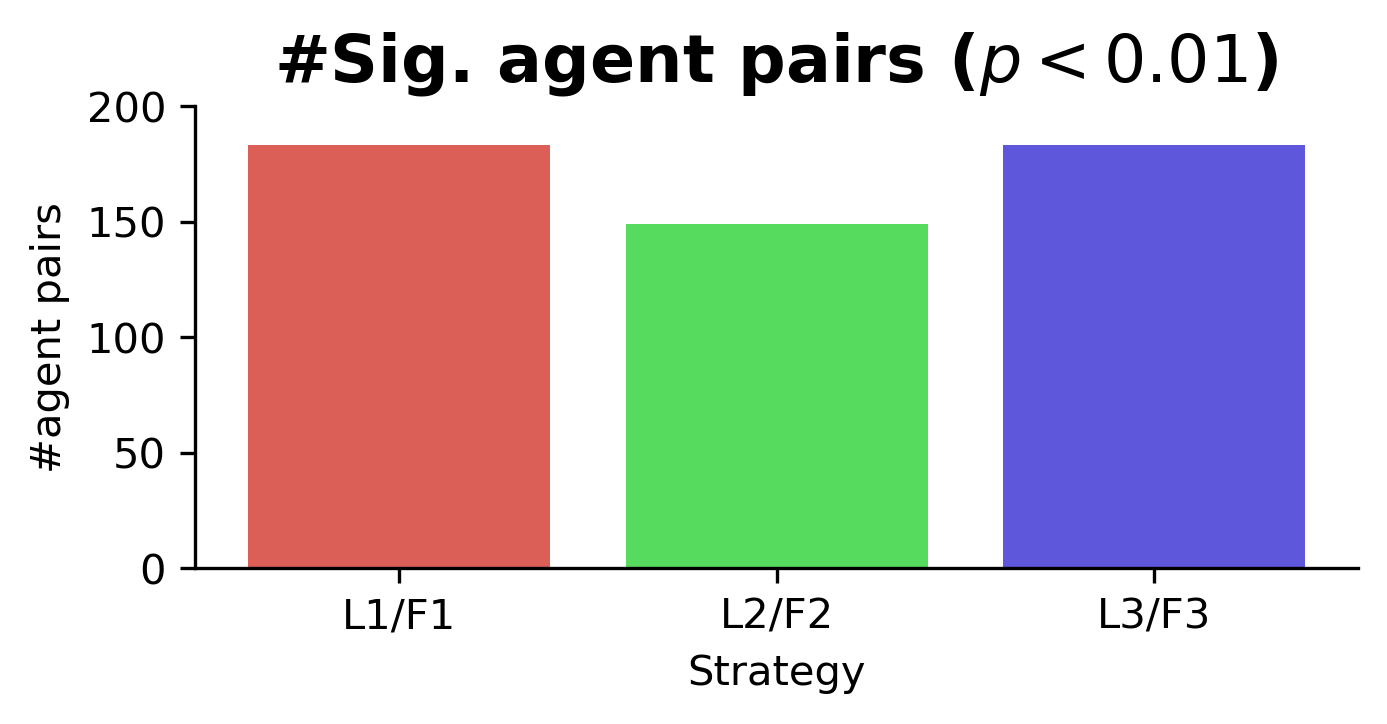

In [11]:
# (s1_btest< 0.01).sum(), (s2_btest< 0.01).sum(), (s3_btest< 0.01).sum()
# bar plot with that
fig, ax = plt.subplots(figsize=(5, 2), dpi=300)
ax.bar(["L1/F1", "L2/F2", "L3/F3"], [(s1_btest< 0.01).sum(), (s2_btest< 0.01).sum(), (s3_btest< 0.01).sum()], color=mycols)
ax.set_ylabel("#agent pairs")
ax.set_xlabel("Strategy")
ax.set_title("#Sig. agent pairs ($p<0.01$)", fontsize=16, weight='bold')
ax.set_ylim(0, 200)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig("testing_significants.svg", format="svg")

## Label switch counts

In [62]:
s1, s2, s3 = test_strats

s1a1 = np.array([ s["a1"] / (s["a1"] + s["a2"]) for s in s1 ])
s1a2 = np.array([ s["a2"] / (s["a1"] + s["a2"]) for s in s1 ])

s2a1 = np.array([ s["a1"] / (s["a1"] + s["a2"]) for s in s2 ])
s2a2 = np.array([ s["a2"] / (s["a1"] + s["a2"]) for s in s2 ])

s3a1 = np.array([ s["a1"] / (s["a1"] + s["a2"]) for s in s3 ])
s3a2 = np.array([ s["a2"] / (s["a1"] + s["a2"]) for s in s3 ])

tsig = (test_sig.s1 < 0.01) & (test_sig.s2 < 0.01)

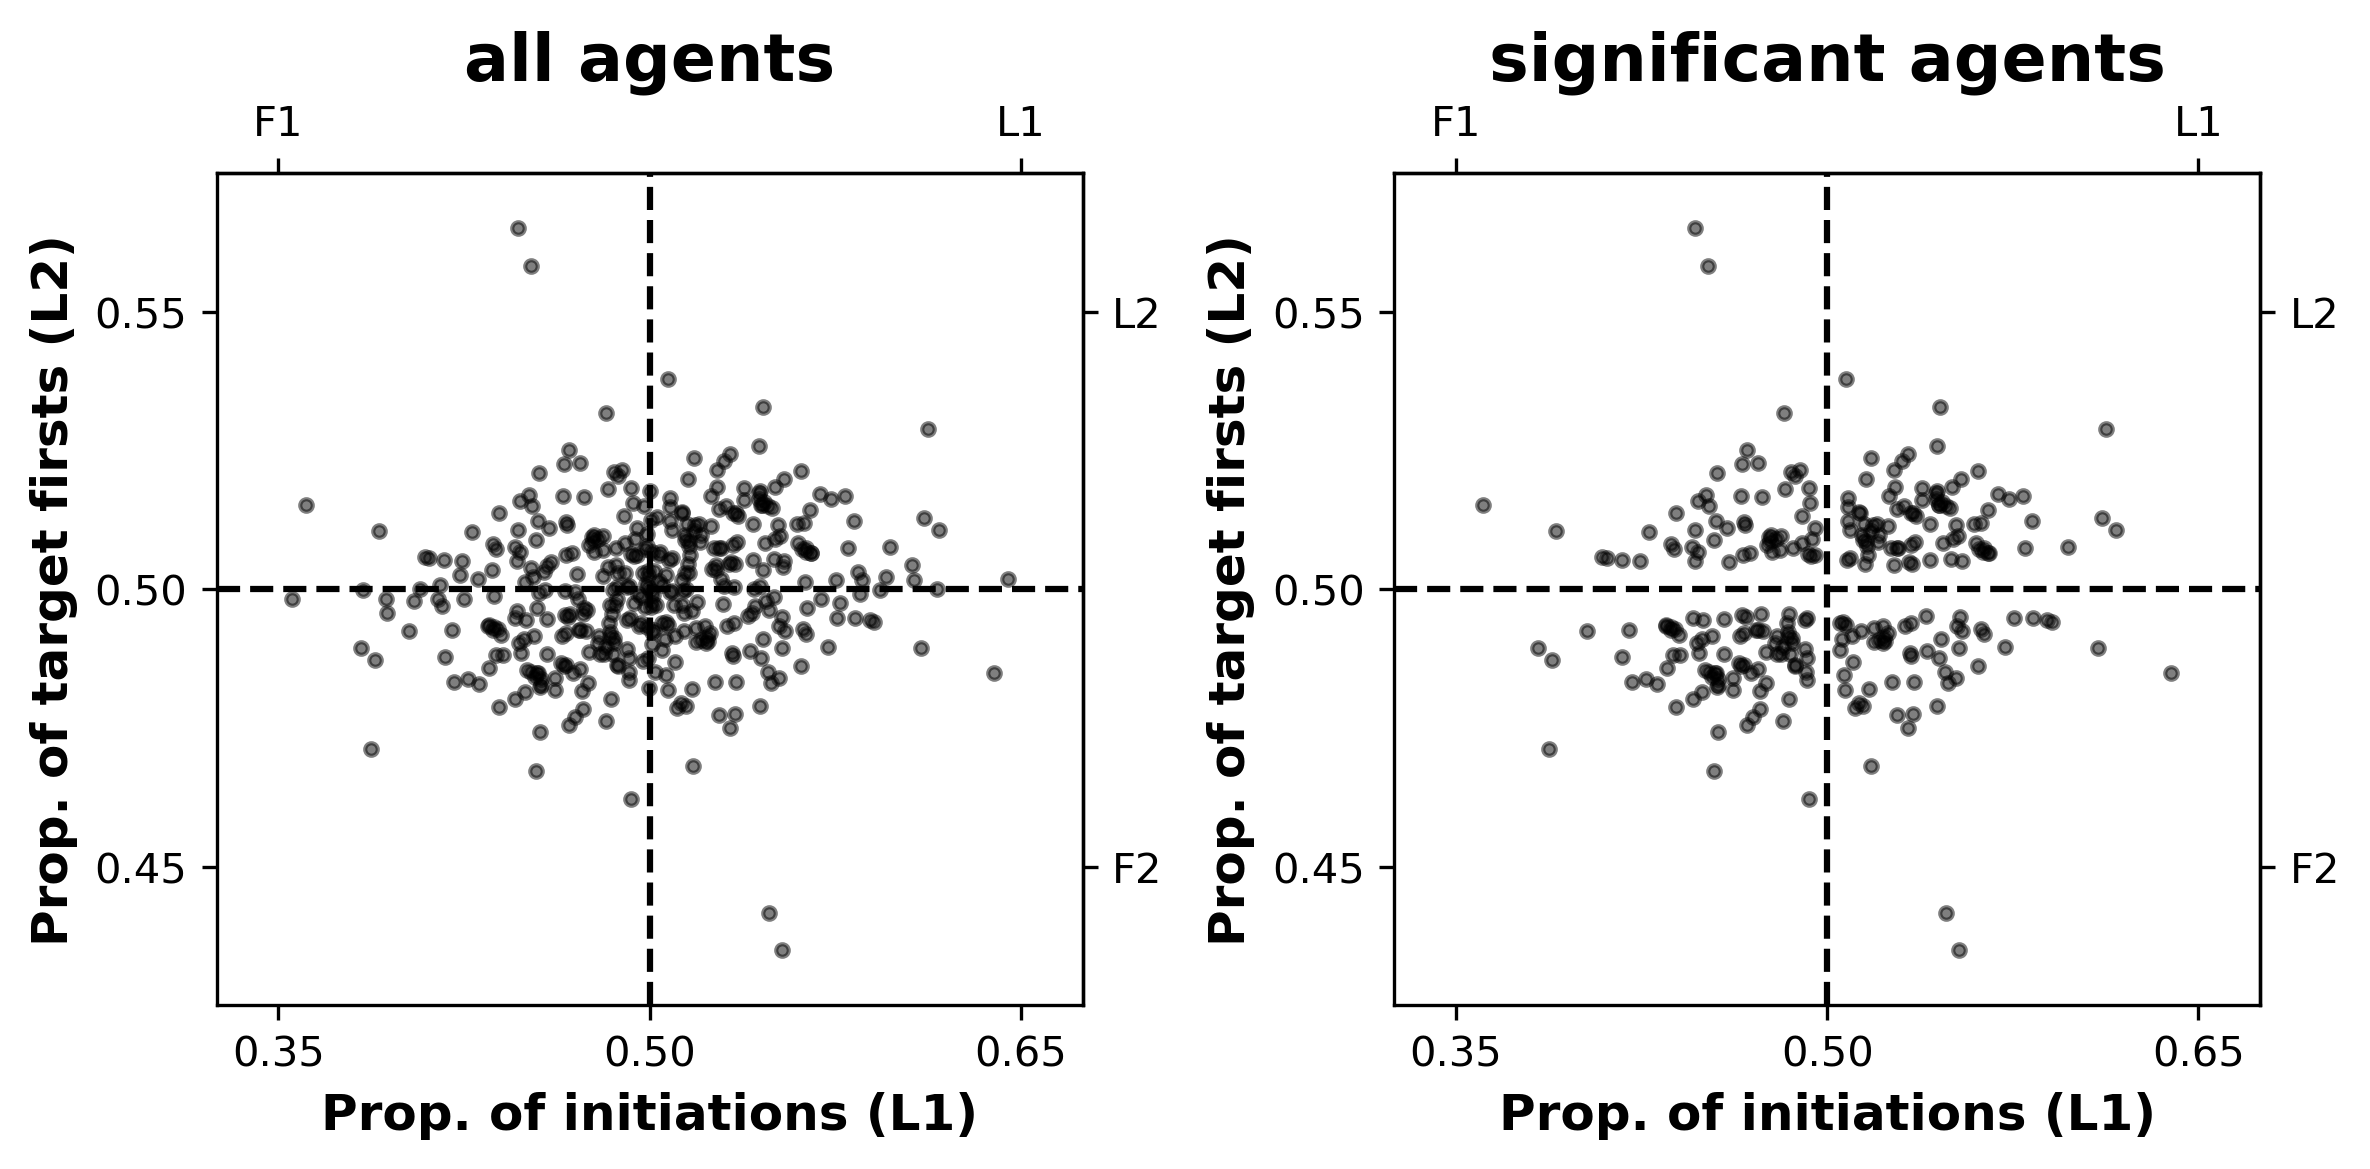

In [63]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4),  dpi = 300)

# Plotting your data (replace these with your actual arrays)
ax[0].plot(s1a1, s2a1, ".", alpha=0.5, color="k", label="a1")
ax[0].plot(s1a2, s2a2, ".", alpha=0.5, color="k", label="a2")

ax[1].plot(s1a1[tsig], s2a1[tsig], ".", alpha=0.5, color="k", label="a1")
ax[1].plot(s1a2[tsig], s2a2[tsig], ".", alpha=0.5, color="k", label="a2")

# Loop over each subplot to set up the axes
for i in range(2):
    # Add vertical and horizontal dashed lines at 0.5
    ax[i].axvline(0.5, color='k', linestyle='--')
    ax[i].axhline(0.5, color='k', linestyle='--')
    
    # Set limits for zoomed view
    ax[i].set_xlim(0.325, 0.675)
    ax[i].set_ylim(0.425, 0.575)
    ax[i].set_yticks([0.45, 0.5, 0.55])
    ax[i].set_xticks([0.35, 0.5, 0.65])
    
    # Set bottom and left labels and title
    ax[i].set_xlabel("Prop. of initiations (L1)", fontsize=12, weight='bold')
    ax[i].set_ylabel("Prop. of target firsts (L2)", fontsize=12, weight='bold')
    ax[i].set_title(["all agents", "significant agents"][i], fontsize=16, weight='bold')
    
    # Create secondary x-axis on the top and set its ticks:
    # At x=0.35 (left) label "F1" and x=0.65 (right) label "L1"
    secax_x = ax[i].secondary_xaxis('top')
    secax_x.set_xticks([0.35, 0.65])
    secax_x.set_xticklabels(["F1", "L1"])
    
    # Create secondary y-axis on the right and set its ticks:
    # At y=0.4 (bottom) label "F2" and y=0.6 (top) label "L2"
    secax_y = ax[i].secondary_yaxis('right')
    secax_y.set_yticks([0.45, 0.55])
    secax_y.set_yticklabels(["F2", "L2"])

plt.tight_layout()
plt.savefig("testing_l1_l2_scatter.svg", format="svg")

In [64]:
tsig.sum()

np.int64(139)

In [69]:
ts1 = np.concat([s1a1[tsig], s1a2[tsig]], axis=0)
ts2 = np.concat([s2a1[tsig], s2a2[tsig]], axis=0)
# ts1 = s1a1[tsig]
# ts2 = s2a1[tsig]

In [70]:
ts1.shape, ts2.shape

((278,), (278,))

In [71]:
l1_l2 = ((ts1 > 0.01) & (ts2 > 0.01)).sum()
l1_f2 = ((ts1 > 0.01) & (ts2 < 0.01)).sum()
f1_l2 = ((ts1 < 0.01) & (ts2 > 0.01)).sum()
f1_f2 = ((ts1 < 0.01) & (ts2 < 0.01)).sum()
l1_l2, l1_f2, f1_l2, f1_f2

(np.int64(278), np.int64(0), np.int64(0), np.int64(0))

Text(0.5, 1.0, 'Leader/Follower counts')

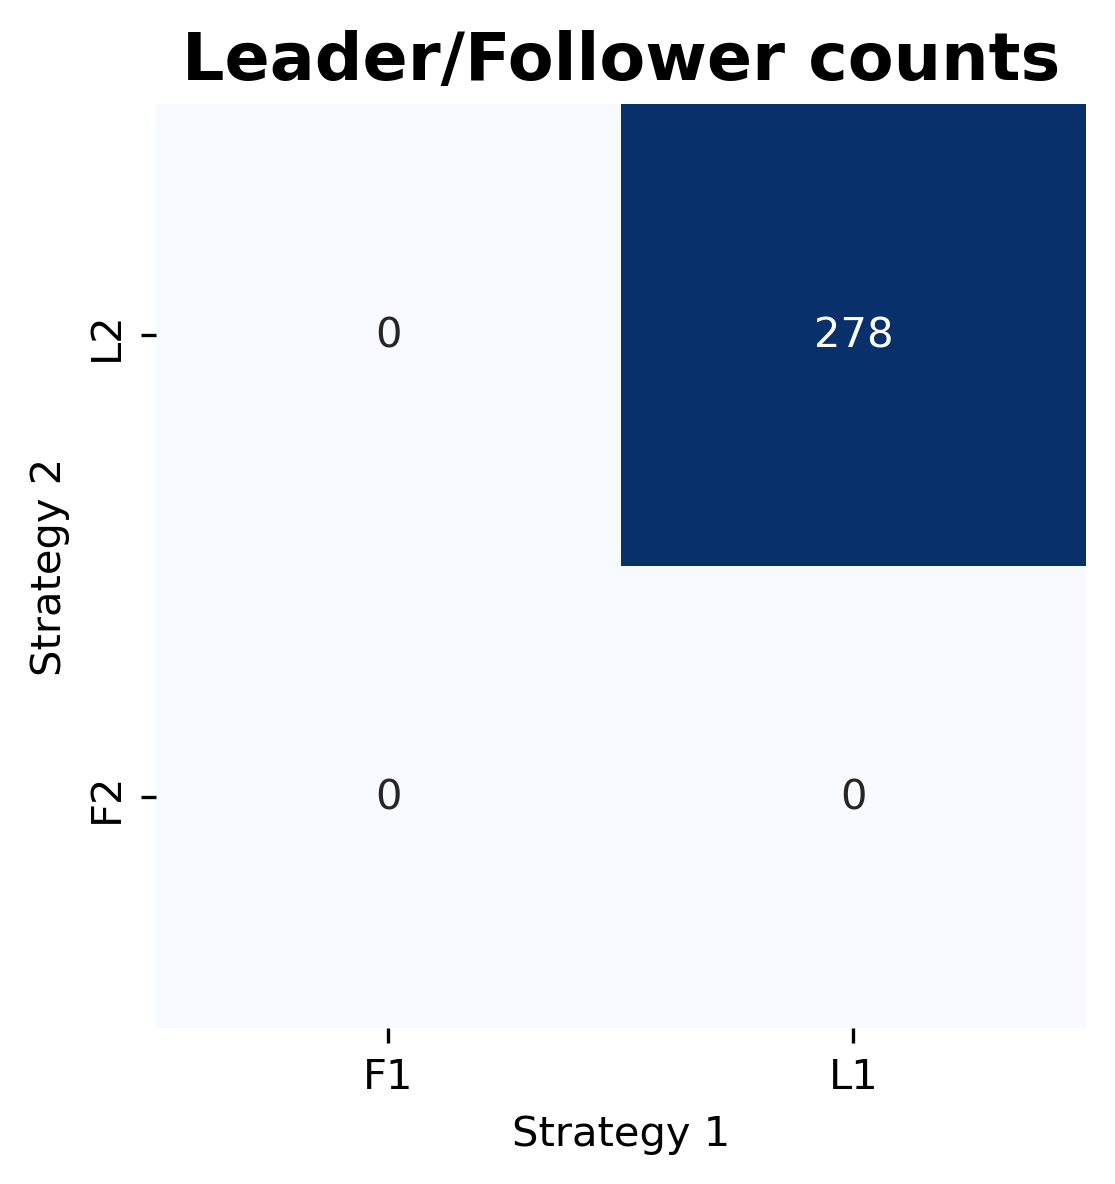

In [72]:
# plot these 4 numbers in a 2x2 heatmap
fig, ax = plt.subplots(figsize=(4, 4), dpi=300)
# sns.heatmap([[1,2],[3,4]], annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
sns.heatmap([[f1_l2,l1_l2],[f1_f2,l1_f2]], annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_xticklabels(["F1", "L1"])
ax.set_yticklabels(["L2", "F2"])
ax.set_xlabel("Strategy 1")
ax.set_ylabel("Strategy 2")
ax.set_title("Leader/Follower counts", fontsize=16, weight='bold')

In [73]:
tsig = (test_sig.s1 < 0.01) & (test_sig.s3 < 0.01)

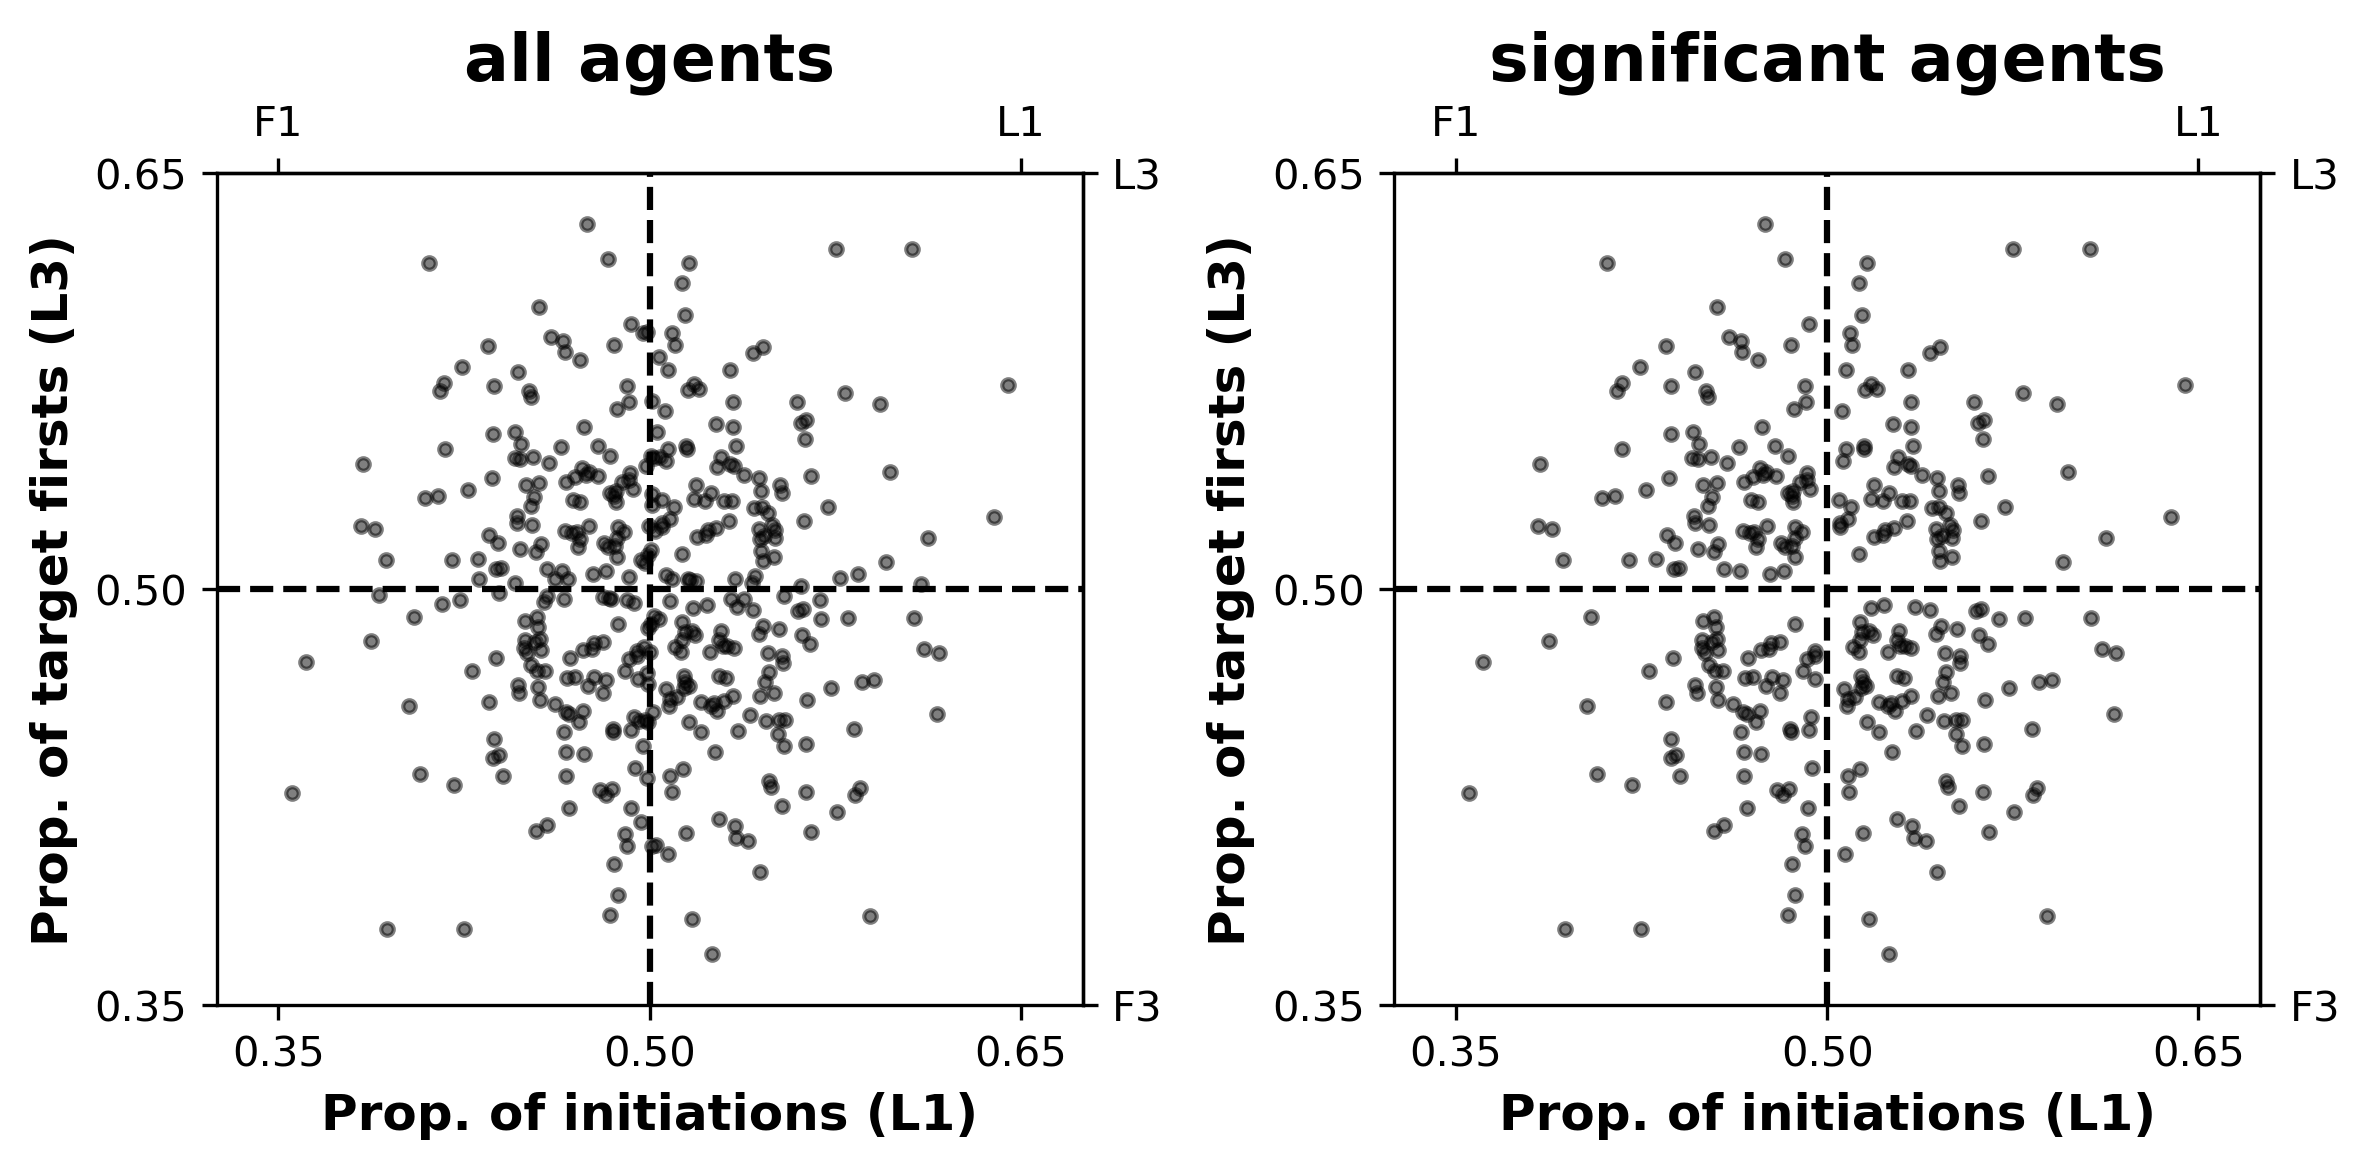

In [74]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4),  dpi = 300)

# Plotting your data (replace these with your actual arrays)
ax[0].plot(s1a1, s3a1, ".", alpha=0.5, color="k", label="a1")
ax[0].plot(s1a2, s3a2, ".", alpha=0.5, color="k", label="a2")

ax[1].plot(s1a1[tsig], s3a1[tsig], ".", alpha=0.5, color="k", label="a1")
ax[1].plot(s1a2[tsig], s3a2[tsig], ".", alpha=0.5, color="k", label="a2")

# Loop over each subplot to set up the axes
for i in range(2):
    # Add vertical and horizontal dashed lines at 0.5
    ax[i].axvline(0.5, color='k', linestyle='--')
    ax[i].axhline(0.5, color='k', linestyle='--')
    
    # Set limits for zoomed view
    ax[i].set_xlim(0.325, 0.675)
    ax[i].set_ylim(0.425, 0.575)
    ax[i].set_yticks([0.35, 0.5, 0.65])
    ax[i].set_xticks([0.35, 0.5, 0.65])
    
    # Set bottom and left labels and title
    ax[i].set_xlabel("Prop. of initiations (L1)", fontsize=12, weight='bold')
    ax[i].set_ylabel("Prop. of target firsts (L3)", fontsize=12, weight='bold')
    ax[i].set_title(["all agents", "significant agents"][i], fontsize=16, weight='bold')
    
    # Create secondary x-axis on the top and set its ticks:
    # At x=0.35 (left) label "F1" and x=0.65 (right) label "L1"
    secax_x = ax[i].secondary_xaxis('top')
    secax_x.set_xticks([0.35, 0.65])
    secax_x.set_xticklabels(["F1", "L1"])
    
    # Create secondary y-axis on the right and set its ticks:
    # At y=0.4 (bottom) label "F2" and y=0.6 (top) label "L2"
    secax_y = ax[i].secondary_yaxis('right')
    secax_y.set_yticks([0.35, 0.65])
    secax_y.set_yticklabels(["F3", "L3"])

plt.tight_layout()
plt.savefig("testing_l1_l3_scatter.svg", format="svg")

In [75]:
ts1 = np.concat([s1a1[tsig], s1a2[tsig]], axis=0)
ts2 = np.concat([s3a1[tsig], s3a2[tsig]], axis=0)

l1_l3 = ((ts1 > 0.01) & (ts2 > 0.01)).sum()
l1_f3 = ((ts1 > 0.01) & (ts2 < 0.01)).sum()
f1_l3 = ((ts1 < 0.01) & (ts2 > 0.01)).sum()
f1_f3 = ((ts1 < 0.01) & (ts2 < 0.01)).sum()
l1_l3, l1_f3, f1_l3, f1_f3

(np.int64(332), np.int64(0), np.int64(0), np.int64(0))

In [16]:
tsig.sum()

NameError: name 'tsig' is not defined

Text(0.5, 1.0, 'L1/L3 counts (total = 166)')

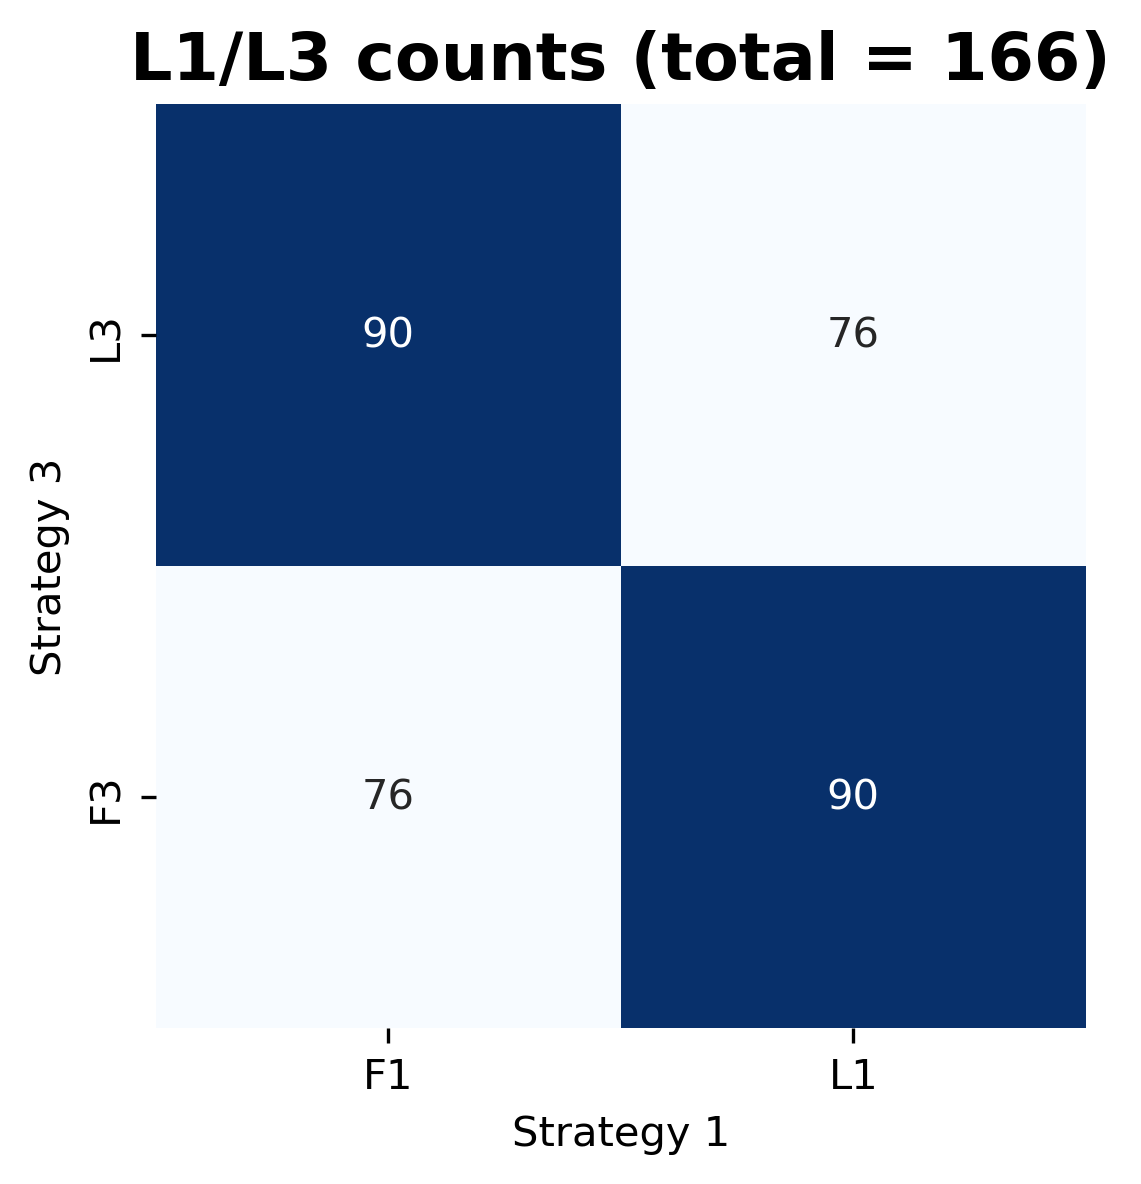

In [213]:
# plot these 4 numbers in a 2x2 heatmap
fig, ax = plt.subplots(figsize=(4, 4), dpi=300)
# sns.heatmap([[1,2],[3,4]], annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
sns.heatmap([[f1_l3,l1_l3],[f1_f3,l1_f3]], annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_xticklabels(["F1", "L1"])
ax.set_yticklabels(["L3", "F3"])
ax.set_xlabel("Strategy 1")
ax.set_ylabel("Strategy 3")
ax.set_title("L1/L3 counts (total = 166)", fontsize=16, weight='bold')

## Qvals

In [76]:
from itertools import product

In [77]:
base= "../store_bk"

qa1, qa2 = [], []
for i in tqdm(range(200)):
    f1 = f"{base}/{i}/qvals/agent_0.pkl"
    f2 = f"{base}/{i}/qvals/agent_1.pkl"
    q1 = pkl.load(open(f1, "rb"))
    q2 = pkl.load(open(f2, "rb"))
    
    qa1.append(q1)
    qa2.append(q2)

100%|██████████| 200/200 [00:19<00:00, 10.24it/s]


In [78]:
reward_states = [None, "ur","rd","dl","ul","ud","rl"]

cq1 = np.zeros((200, 7, 11,11,11,11))
cq2 = np.zeros((200, 7, 11,11,11,11))

for apair in tqdm(range(200)):
    
    for rid, rw in enumerate(reward_states):
        for i in range(11):
            for j in range(11):
                for k in range(11):
                    for l in range(11):
                        state = (((i,j), (k,l)), rw)
                        cq1[apair, rid, i,j,k,l] = qa1[apair][state]
                        cq2[apair, rid, i,j,k,l] = qa1[apair][state]

100%|██████████| 200/200 [00:11<00:00, 17.85it/s]


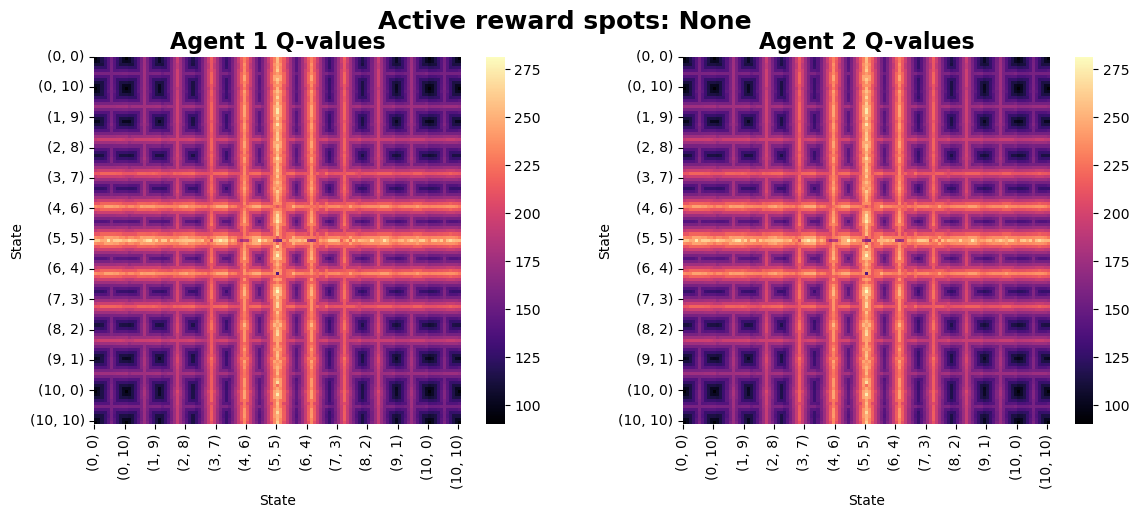

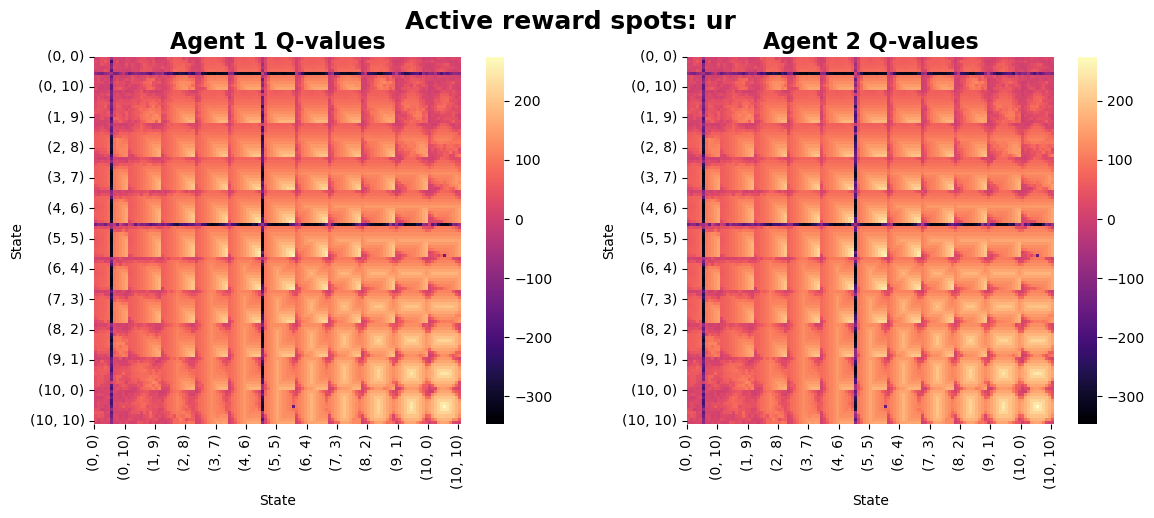

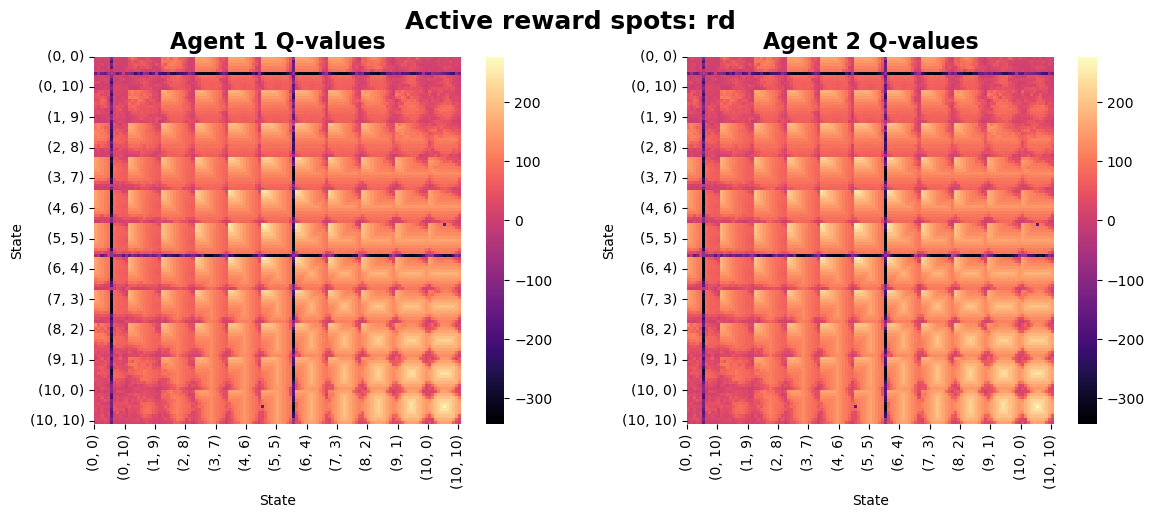

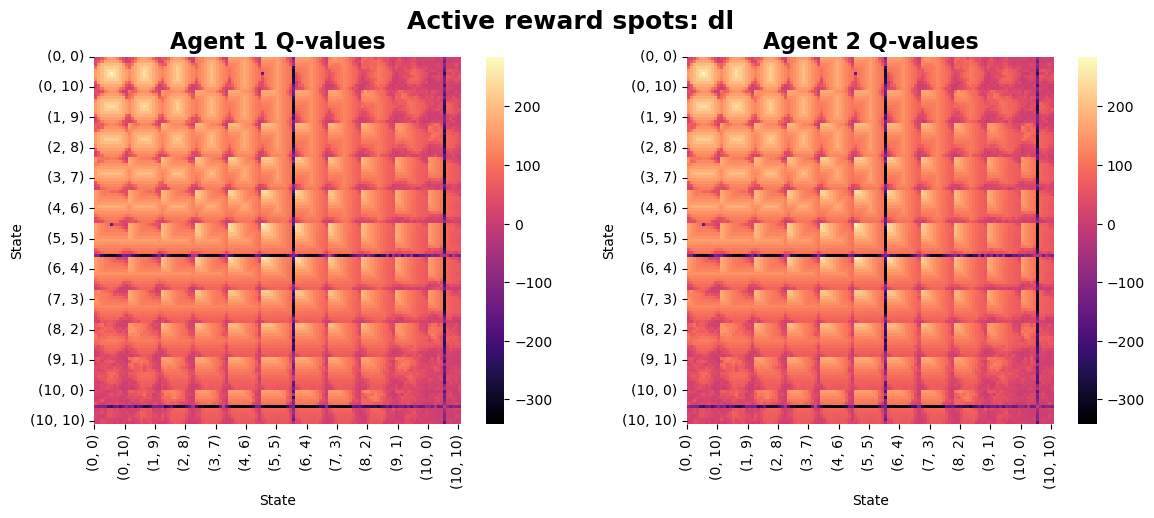

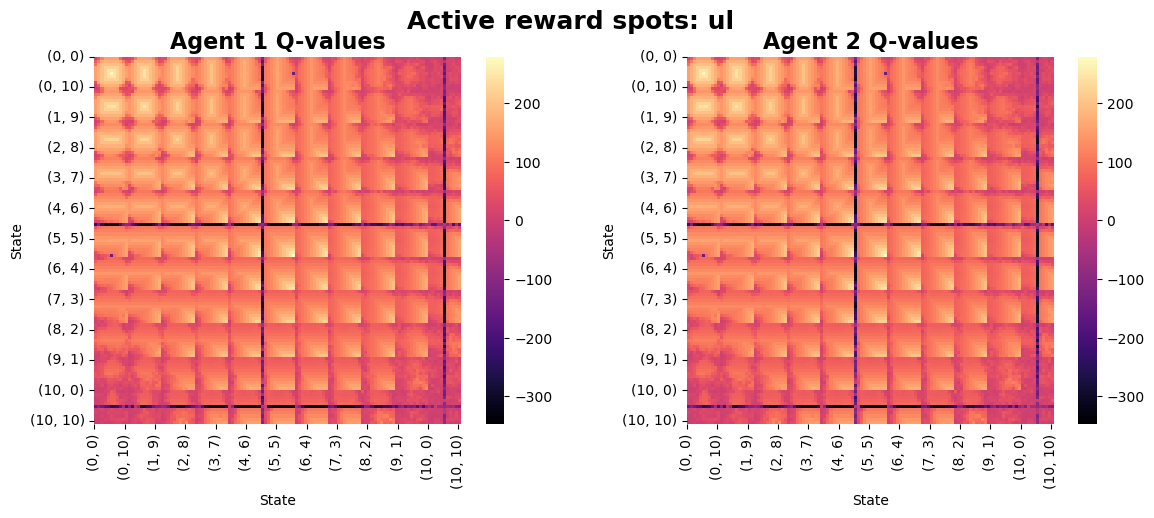

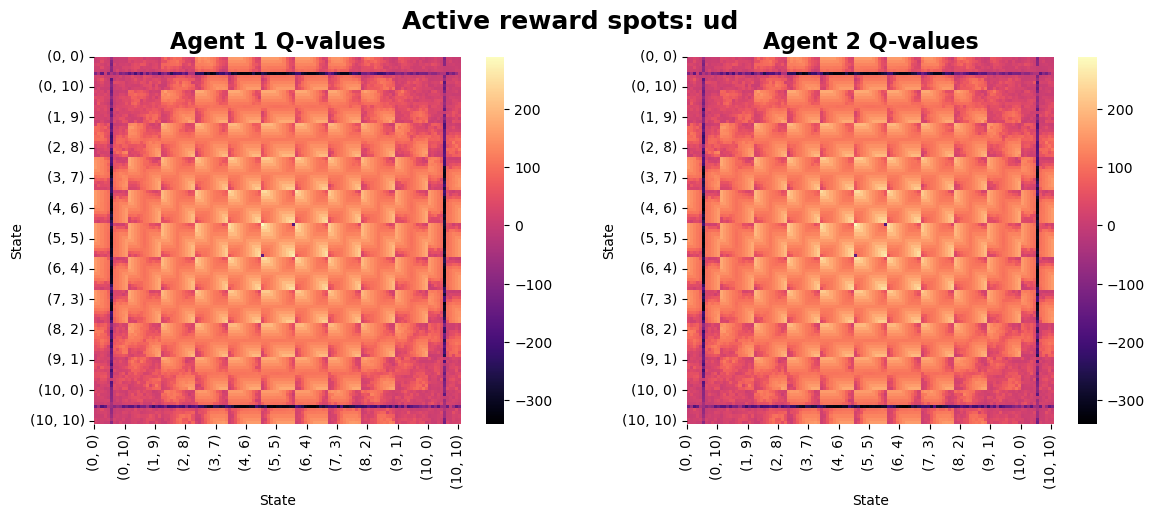

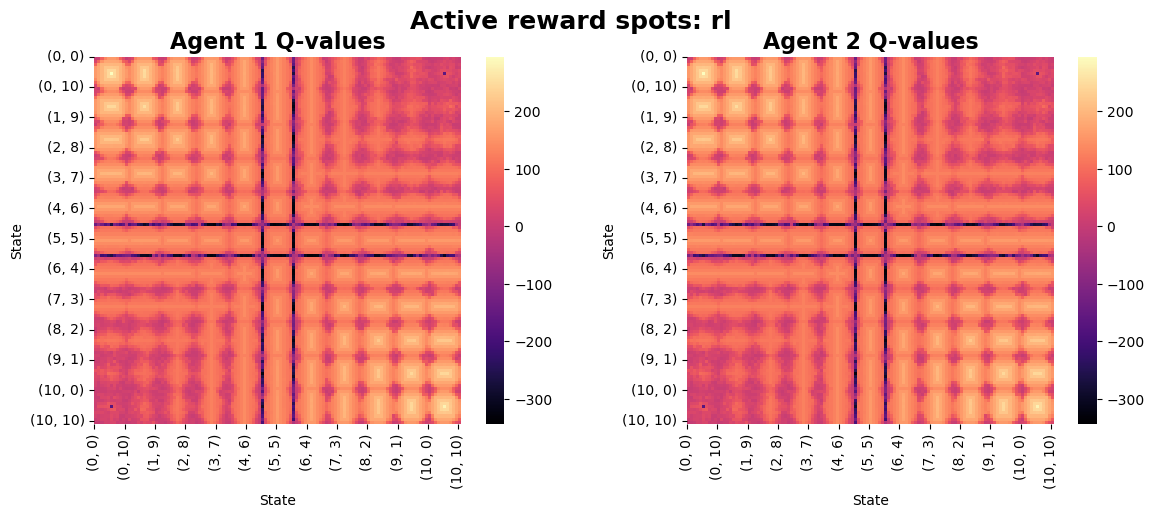

In [80]:
ticks = np.arange(0, 11*11, 1)
tick_labesl = list(product(list(range(11)), repeat=2))

for rw_state in range(7):

    fig, ax = plt.subplots(1,2, figsize=(12, 5))

    sns.heatmap(cq1[0][rw_state].reshape(11*11, 11*11), cmap="magma", cbar=True, ax=ax[0])
    ax[0].set_title("Agent 1 Q-values", fontsize=16, weight='bold')

    sns.heatmap(cq2[0][rw_state].reshape(11*11, 11*11), cmap="magma", cbar=True, ax=ax[1])
    ax[1].set_title("Agent 2 Q-values", fontsize=16, weight='bold')

    for i in range(2):
        ax[i].set_xlabel("State")
        ax[i].set_ylabel("State")
        ax[i].set_xticks(ticks[::10])
        ax[i].set_xticklabels(tick_labesl[::10])
        ax[i].set_yticks(ticks[::10])
        ax[i].set_yticklabels(tick_labesl[::10])
        ax[i].set_aspect('equal')

    plt.suptitle("Active reward spots: "+str(reward_states[rw_state]), fontsize=18, weight='bold')

    plt.tight_layout()
    plt.show()

In [81]:
cq1.shape

(200, 7, 11, 11, 11, 11)

In [82]:
cq1.reshape(200, 7, 11*11, 11*11).shape

(200, 7, 121, 121)

In [83]:
intiq = cq1.reshape(200, 7, 11*11, 11*11)[:, 0, :, :].copy()
zoneq = cq1.reshape(200, 7, 11*11, 11*11)[:, 1:, :, :].copy()

intiq.shape, zoneq.shape

((200, 121, 121), (200, 6, 121, 121))

In [84]:
init_diff = []

for i in range(200):
    diff = np.sum(np.abs(intiq[i] - intiq[i].T))/2
    init_diff.append(diff)

In [85]:
zone_diff = []
for i in range(200):
    tdiff = []
    for j in range(6):
        diff = np.sum(np.abs(zoneq[i, j] - zoneq[i, j].T))/2
        tdiff.append(diff)
    zone_diff.append(np.mean(tdiff))

In [86]:
zone_diff = np.array(zone_diff)
init_diff = np.array(init_diff)

In [87]:
# ns1, s1_btest
st1_assym = (ns1.a1 - ns1.a2).abs().values * 100
st2_assym = (ns2.a1 - ns2.a2).abs().values * 100
st3_assym = (ns3.a1 - ns3.a2).abs().values * 100

Text(0.5, 1.0, 'Initiator assymetry vs qvalue diff.')

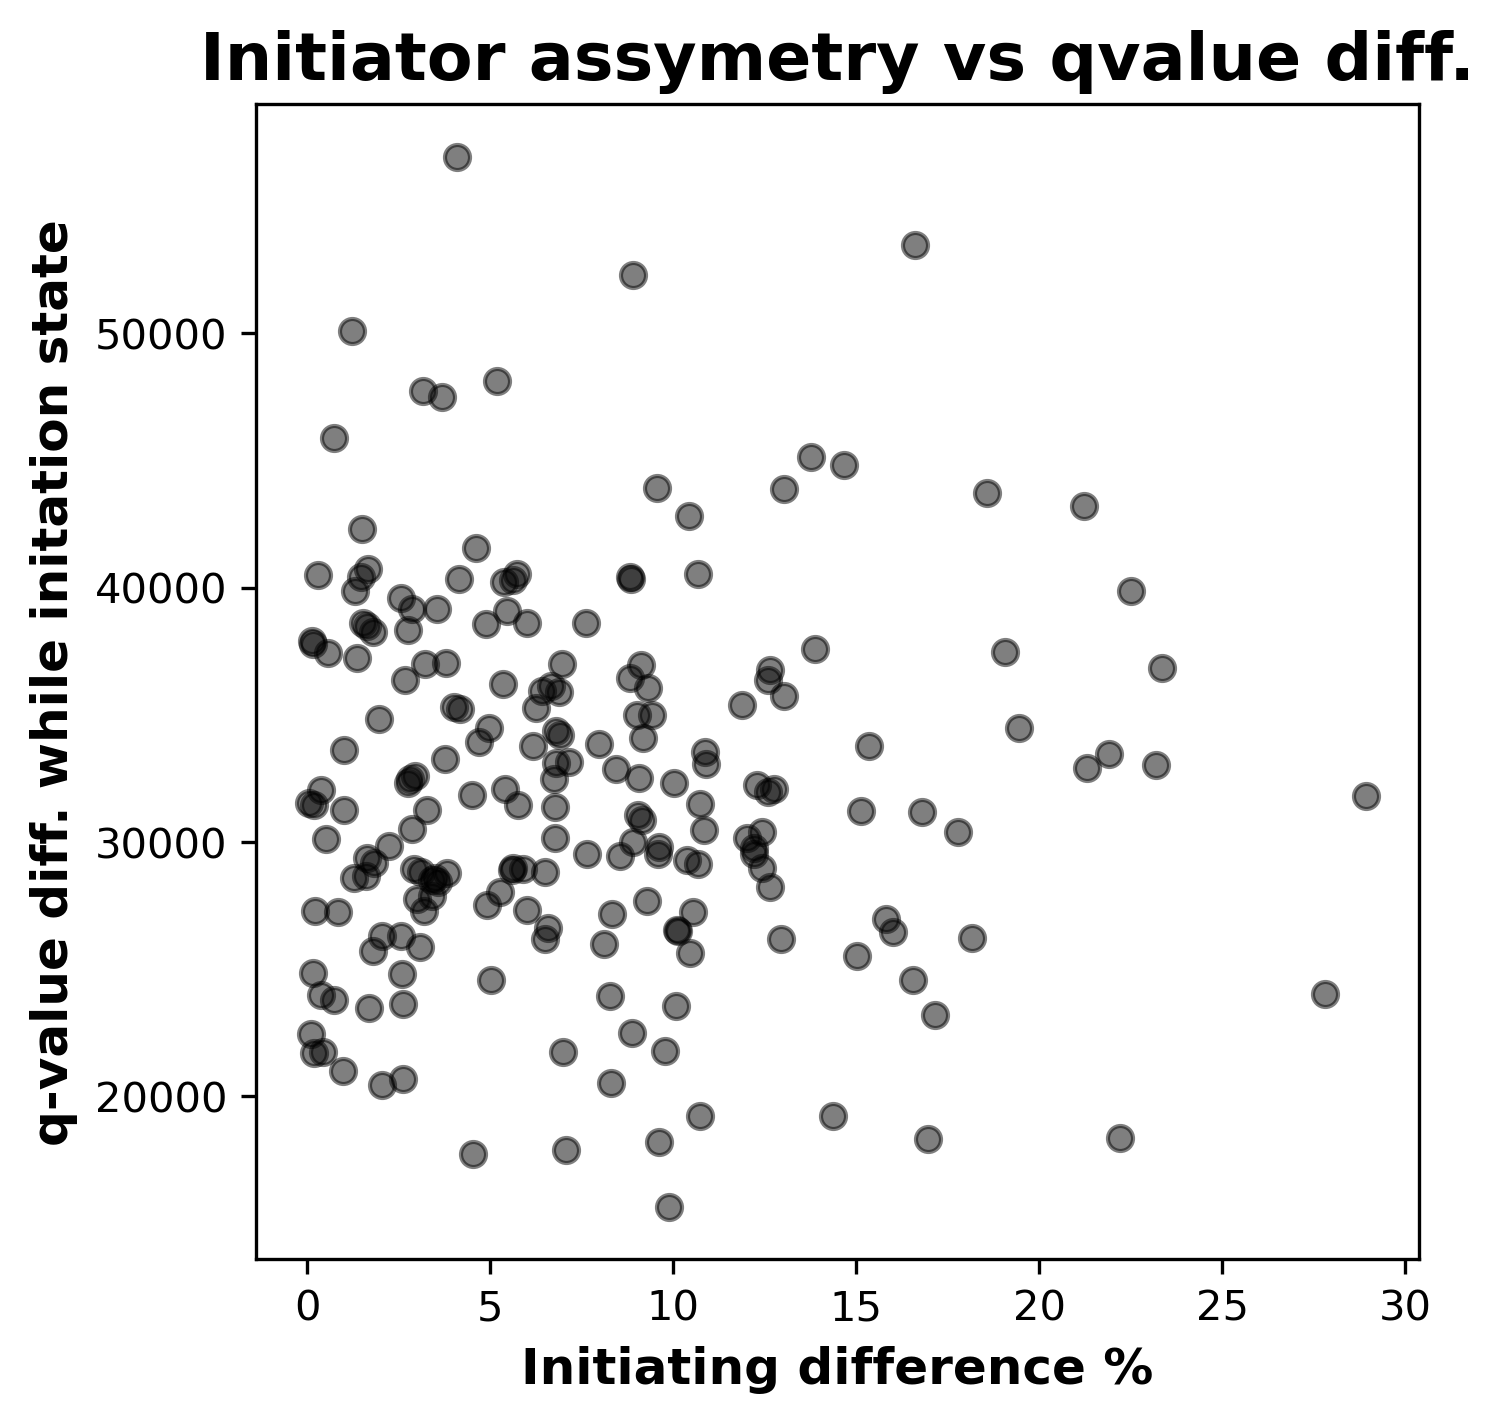

In [95]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.scatter(st1_assym, init_diff, alpha=0.5, color="k")

ax.set_xlabel("Initiating difference %", fontsize=12, weight='bold')
ax.set_ylabel("q-value diff. while initation state", fontsize=12, weight='bold')
ax.set_title("Initiator assymetry vs qvalue diff.", fontsize=16, weight='bold')

Text(0.5, 1.0, 'Leader assymetry vs qvalue diff.')

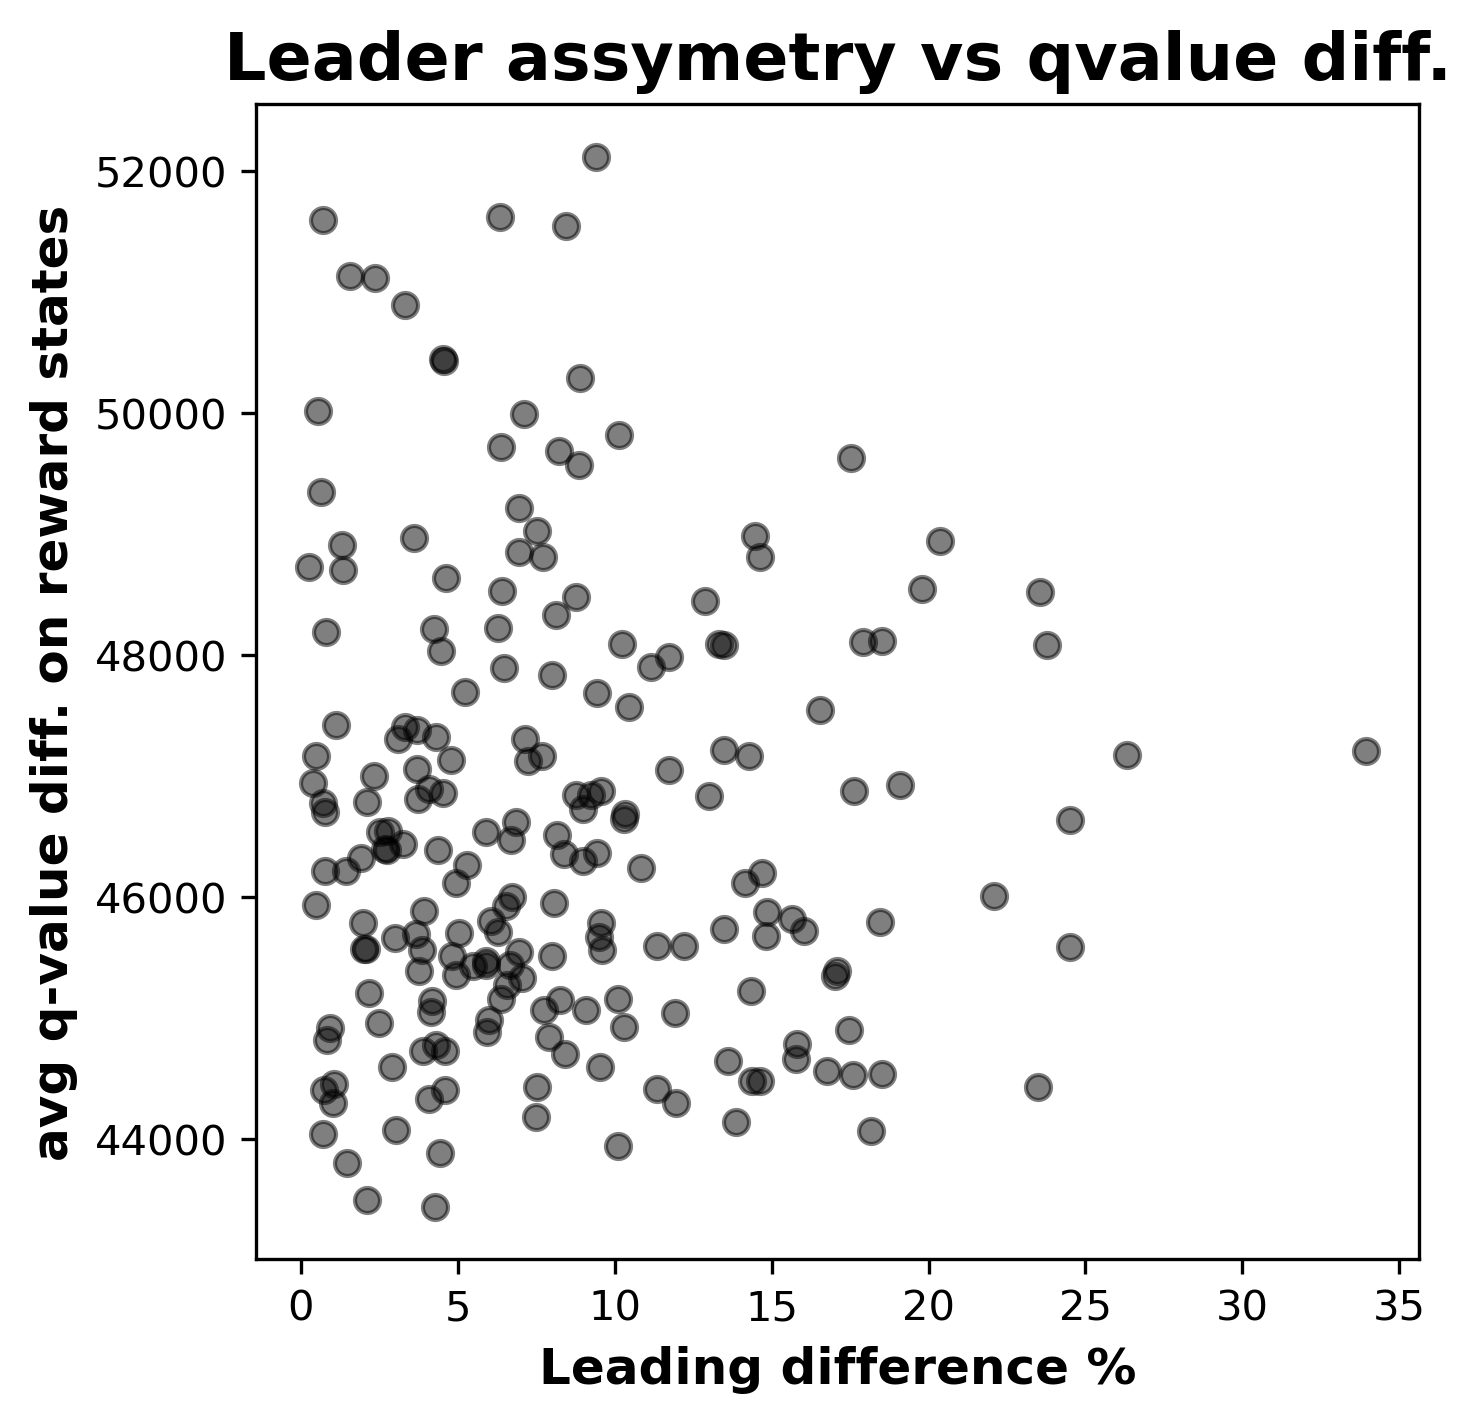

In [97]:
fig, ax = plt.subplots(figsize=(5, 5), dpi =300)

ax.scatter(st3_assym, zone_diff, alpha=0.5, color="k")

ax.set_xlabel("Leading difference %", fontsize=12, weight='bold')
ax.set_ylabel("avg q-value diff. on reward states", fontsize=12, weight='bold')
ax.set_title("Leader assymetry vs qvalue diff.", fontsize=16, weight='bold')

In [87]:
zone_diff

array([1544448.60781104, 1539852.47969973, 1531590.52646766,
       1547958.91058157, 1534081.19991906, 1531816.66679772,
       1524735.15464155, 1532491.4768267 , 1537813.46367849,
       1539818.74926942, 1530151.21997393, 1522845.31435843,
       1519077.43876501, 1533444.75764714, 1544958.95761883,
       1523669.95725599, 1541710.13311905, 1512197.59492782,
       1554431.25113501, 1521991.74674672, 1531698.7947806 ,
       1523609.34134879, 1531030.20210538, 1535158.3309687 ,
       1530347.52027756, 1531585.55095655, 1532488.18164561,
       1524918.38257562, 1530305.5035505 , 1530734.31968648,
       1535250.52815216, 1536212.5801727 , 1540060.01554833,
       1520115.14942595, 1531367.48569295, 1541284.80914277,
       1526864.75342209, 1533917.56114886, 1536883.90466853,
       1528759.31943818, 1550956.35091935, 1549139.22647209,
       1530276.72225596, 1535159.55554593, 1536838.16104567,
       1535883.69533444, 1546267.57578337, 1529676.24652254,
       1526296.92526534,

## Training

In [109]:
base= "../store_bk"
trains = sorted(os.listdir(base))

strat_1 = []
strat_2 = []
strat_3 = []

train_tt = []

for i in tqdm(trains[:]):
    f = f"{base}/{i}/trial_stats/training_1.parquet"
    t = pd.read_parquet(f)
    train_tt.append(t.trial_id.max())
    strat_1.append(t.activated_by.value_counts().to_dict())
    strat_2.append(t.first_close_to_zone.value_counts().to_dict())
    strat_3.append(t.first_to_zone.value_counts().to_dict())

100%|██████████| 200/200 [00:37<00:00,  5.39it/s]


In [110]:
l1 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_1]
f1 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_1]

l2 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_2]
f2 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_2]

l3 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_3]
f3 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_3]

# renamed mouse list
mst1 = []
mst2 = []
mst3 = []

for i in leader_index:
    mst1.append({ "a1": strat_1[i][l1[i]], "a2": strat_1[i][f1[i]] })
    mst2.append({ "a1": strat_2[i][l1[i]], "a2": strat_2[i][f1[i]] })
    mst3.append({ "a1": strat_3[i][l1[i]], "a2": strat_3[i][f1[i]] })
for j in follower_index:
    mst1.append({ "a1": strat_1[j][f1[j]], "a2": strat_1[j][l1[j]] })
    mst2.append({ "a1": strat_2[j][f1[j]], "a2": strat_2[j][l1[j]] })
    mst3.append({ "a1": strat_3[j][f1[j]], "a2": strat_3[j][l1[j]] })
    
strat_1 = mst1
strat_2 = mst2
strat_3 = mst3

In [111]:
test_strats = (strat_1, strat_2, strat_3)

cols = ["a1", "a2", "tie"]
strat_1 = pd.DataFrame(strat_1, columns=cols)
strat_2 = pd.DataFrame(strat_2, columns=cols)
strat_3 = pd.DataFrame(strat_3, columns=cols)

strat_1 = strat_1.fillna(0).astype(int)
strat_2 = strat_2.fillna(0).astype(int)
strat_3 = strat_3.fillna(0).astype(int)

s1_btest = pd.Series(do_btest(strat_1), name="pval")
s2_btest = pd.Series(do_btest(strat_2), name="pval")
s3_btest = pd.Series(do_btest(strat_3), name="pval")

l1 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_1.to_dict(orient="records")]
f1 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_1.to_dict(orient="records")]

l2 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_2.to_dict(orient="records")]
f2 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_2.to_dict(orient="records")]

test_sig = pd.DataFrame({
    "l1": [ strat_1.iloc[i][l1[i]] for i in range(len(l1))],
    "f1": [ strat_1.iloc[i][f1[i]] for i in range(len(f1))],
    "s1": s1_btest,
    "l2": [ strat_2.iloc[i][l2[i]] for i in range(len(l2))],
    "f2": [ strat_2.iloc[i][f2[i]] for i in range(len(f2))],
    "s2": s2_btest,
})

In [112]:
ns1 = strat_1[["a1", "a2"]] / strat_1[["a1", "a2"]].sum(axis=1).values[:, None]
ns2 = strat_2[["a1", "a2"]] / strat_2[["a1", "a2"]].sum(axis=1).values[:, None]
ns3 = strat_3[["a1", "a2"]] / strat_3[["a1", "a2"]].sum(axis=1).values[:, None]

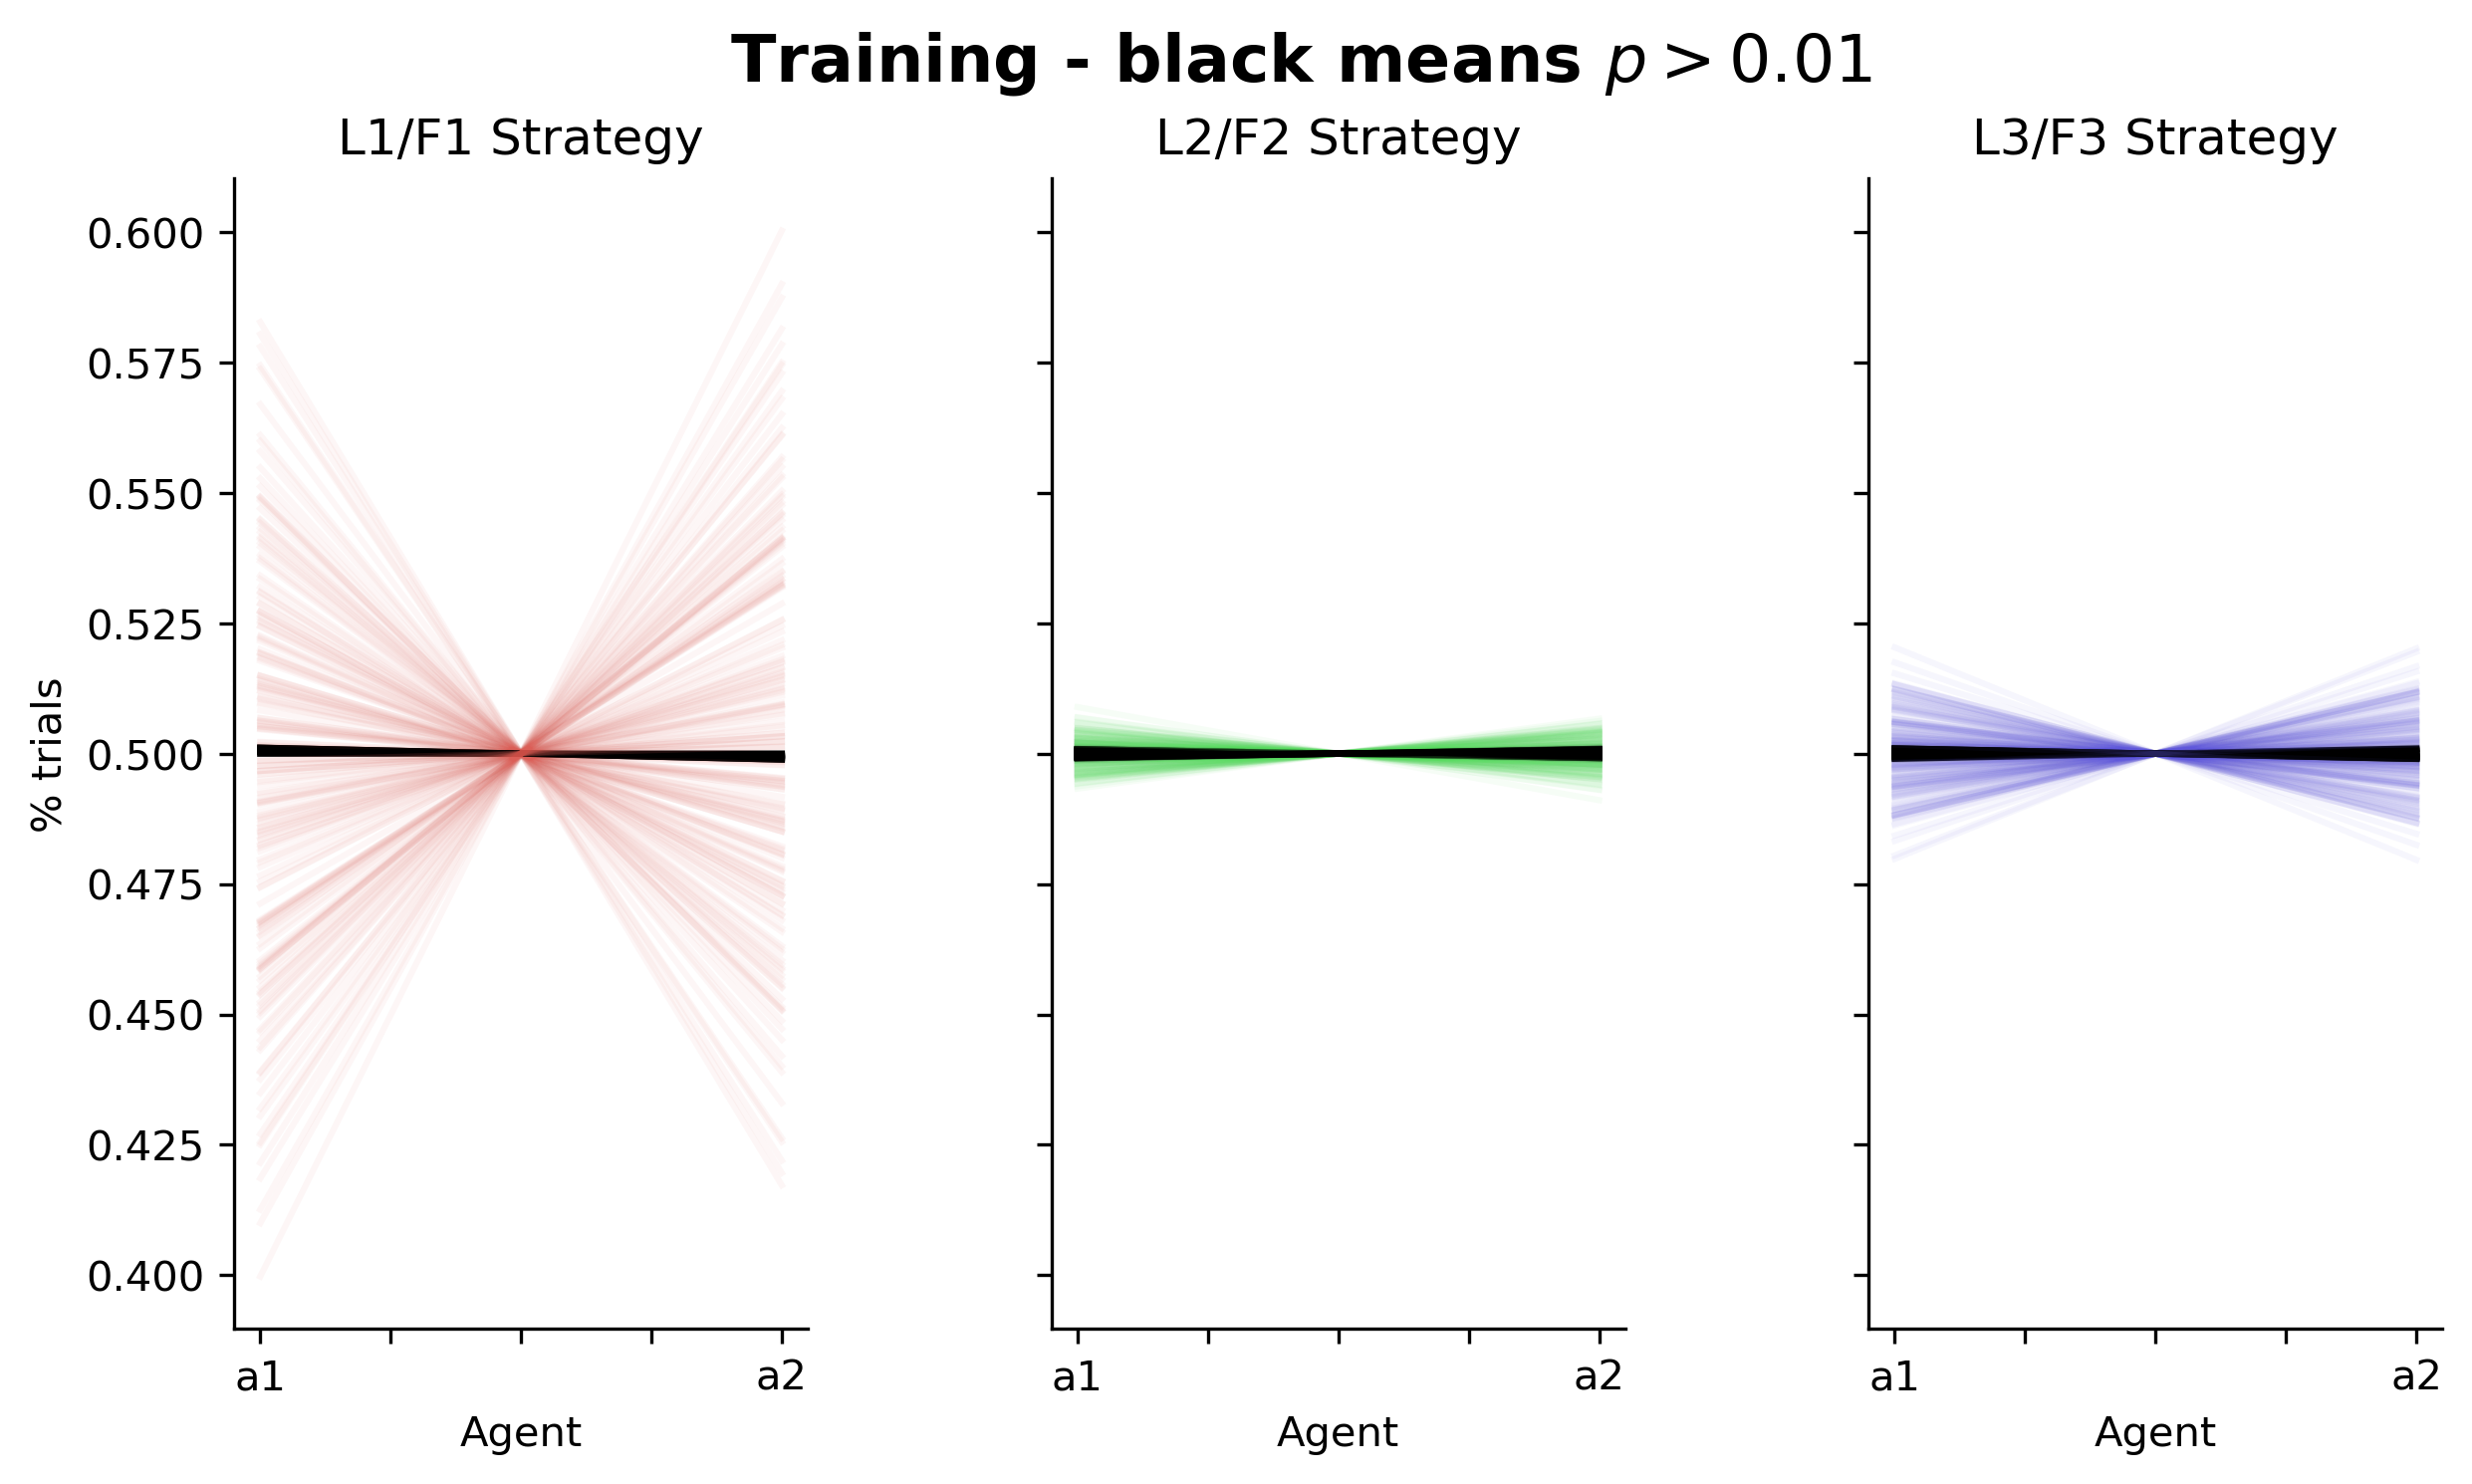

In [ ]:
insig_color = "black"
fig, ax = plt.subplots(1, 3, figsize=(10, 5), dpi=300, sharey=True)
for i in range(len(ns1)):
    significant = s1_btest[i] < 0.01
    color = mycols[0] if significant else insig_color
    alpha = 0.01 if significant else 1
    label = "significant" if significant else "insignificant"
    ns1.iloc[i].plot(ax=ax[0], color=color, alpha=alpha, label=label)
    
    color = mycols[1] if s2_btest[i] < 0.01 else insig_color
    alpha = 0.01 if s2_btest[i] < 0.01 else 1
    label = "significant" if s2_btest[i] < 0.01 else "insignificant"
    ns2.iloc[i].plot(ax=ax[1], color=color, alpha=alpha, label=label)
    
    color = mycols[2] if s3_btest[i] < 0.01 else insig_color
    alpha = 0.01 if s3_btest[i] < 0.01 else 1
    label = "significant" if s3_btest[i] < 0.01 else "insignificant"
    ns3.iloc[i].plot(ax=ax[2], color=color, alpha=alpha, label=label)

for i in range(3):
    ax[i].set_xlabel("Agent")
    ax[i].set_ylabel("% trials")
    ax[i].set_title(titles[i])
    ax[i].set_aspect(10)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

plt.suptitle("Training - black means $p>0.01$", fontsize=16, weight='bold')
# plt.tight_layout()
# plt.show()
plt.savefig("training_proportions.svg", format="svg")

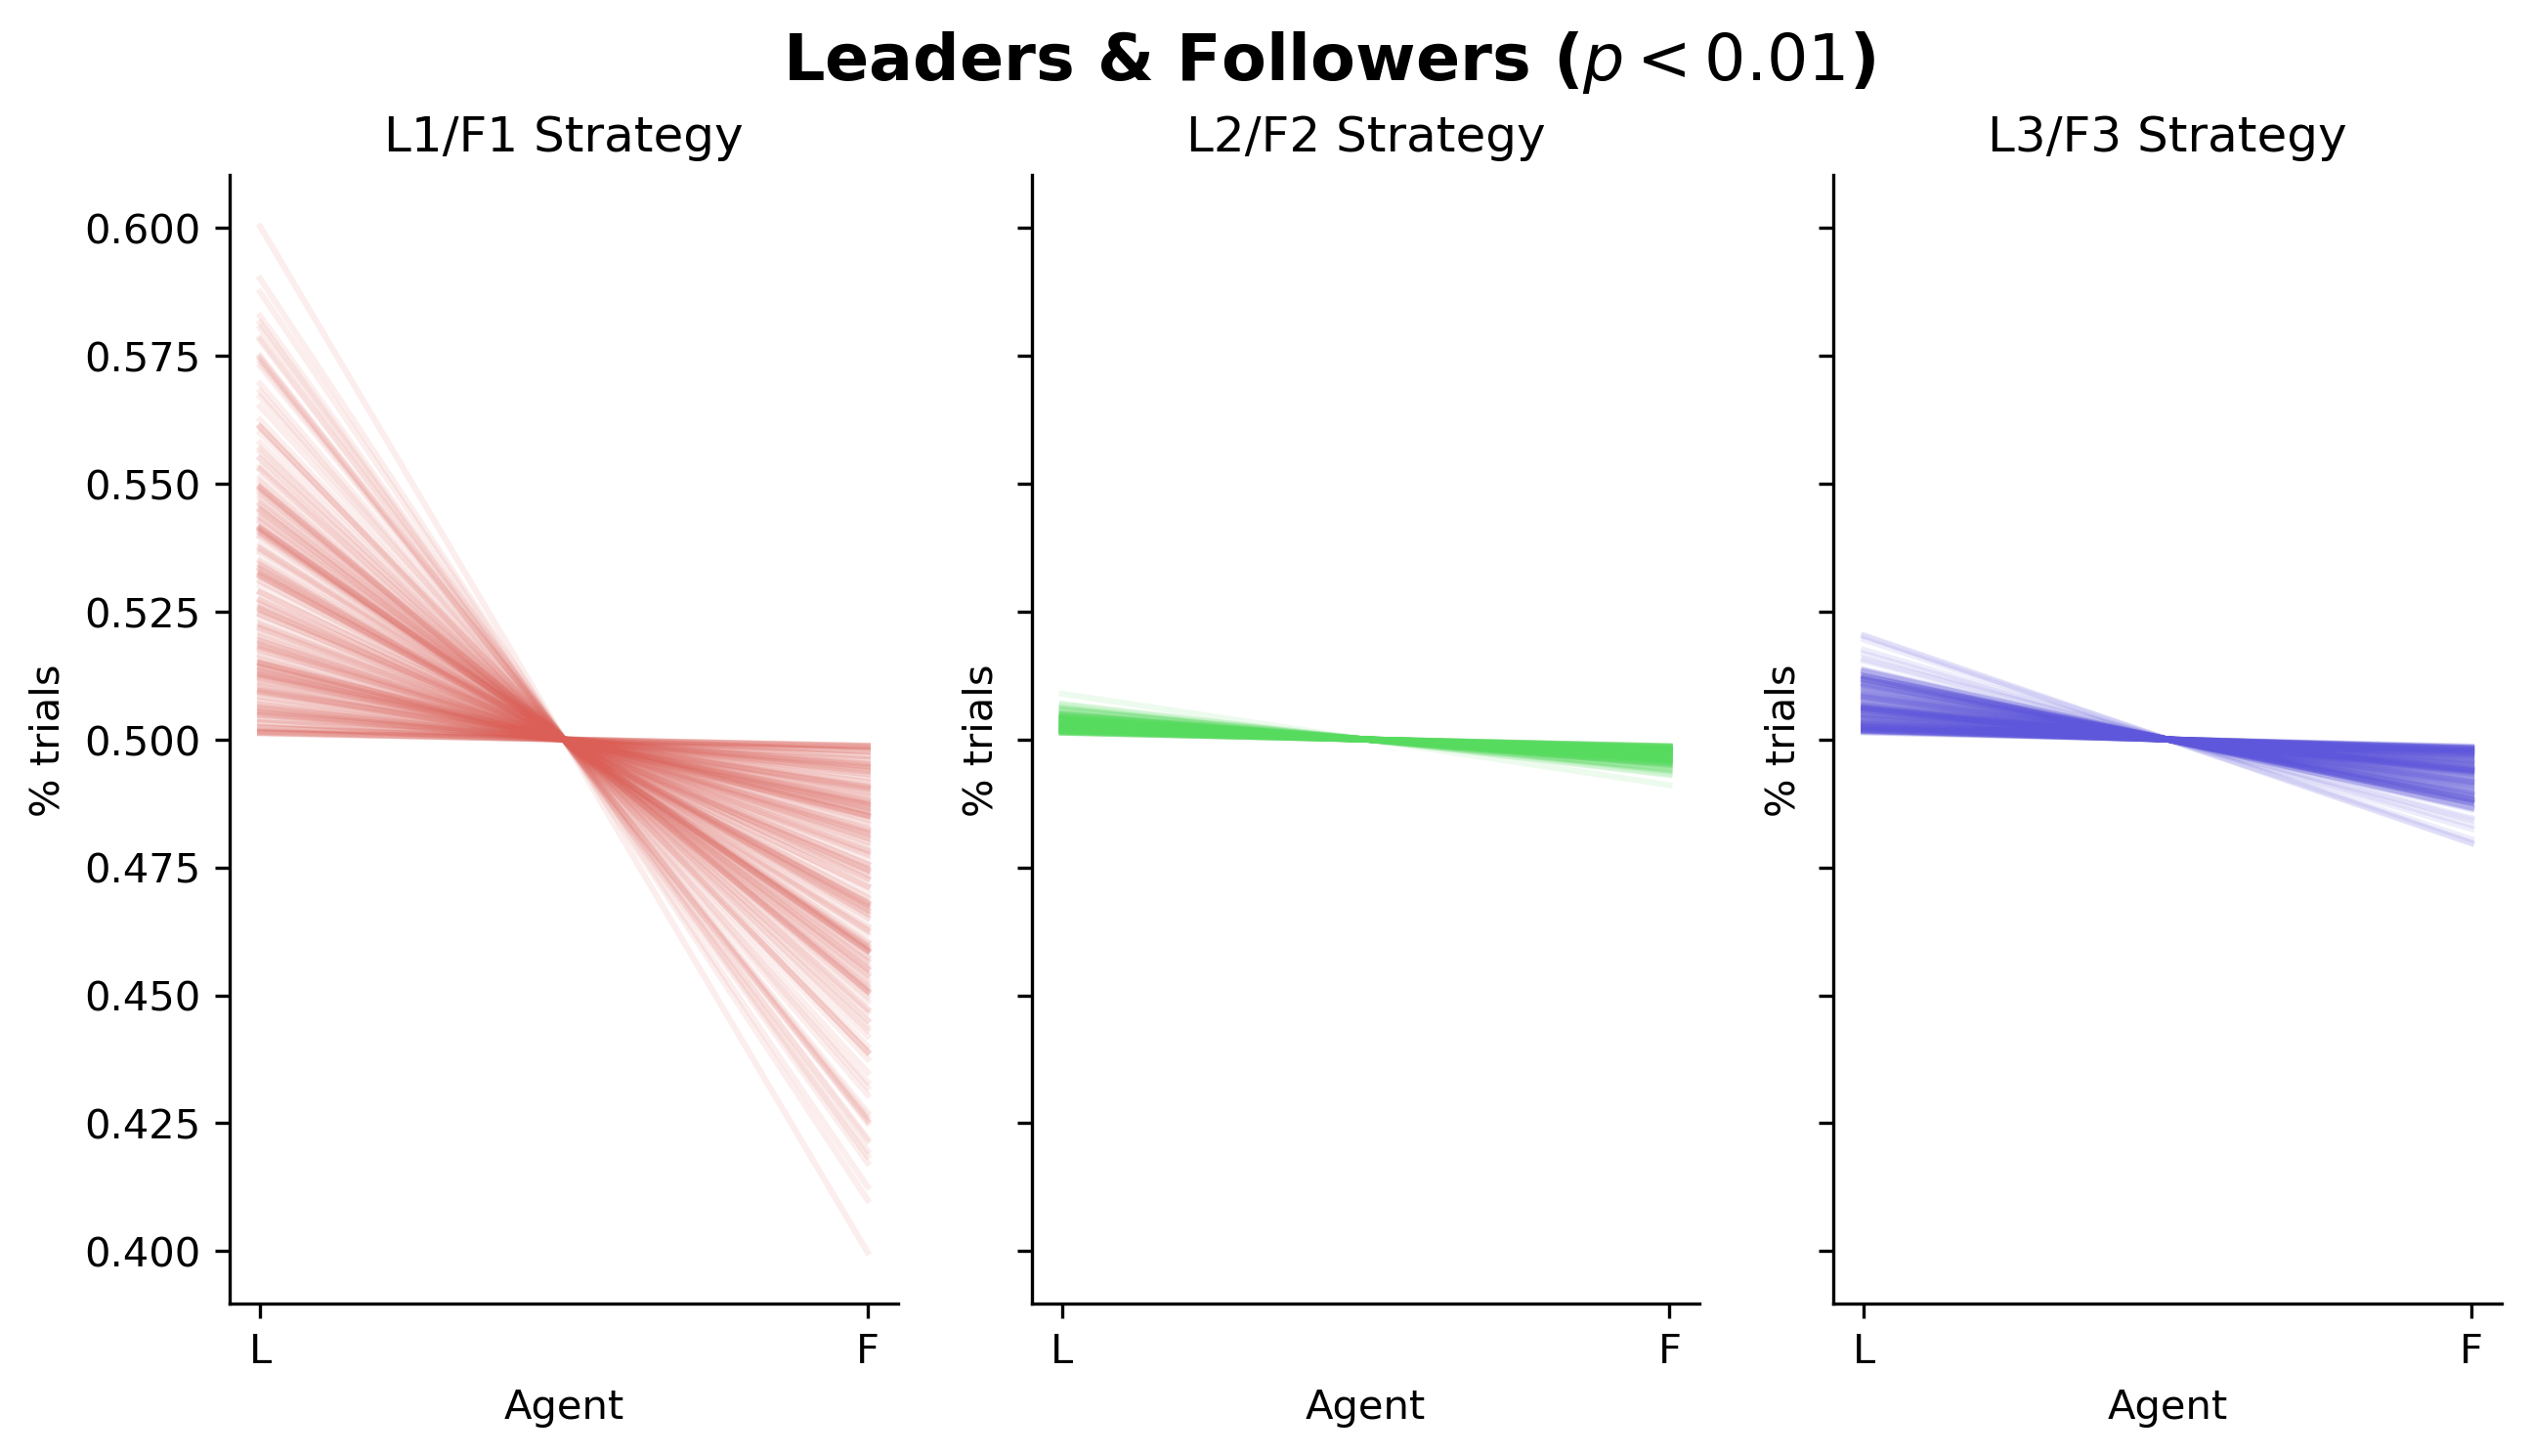

In [114]:
titles = ["L1/F1 Strategy", "L2/F2 Strategy", "L3/F3 Strategy"]
mycols = sns.hls_palette(n_colors=3, h=0.01, l=0.6, s=0.65, as_cmap=False)

ns1 = strat_1[["a1", "a2"]] / strat_1[["a1", "a2"]].sum(axis=1).values[:, None]
ns2 = strat_2[["a1", "a2"]] / strat_2[["a1", "a2"]].sum(axis=1).values[:, None]
ns3 = strat_3[["a1", "a2"]] / strat_3[["a1", "a2"]].sum(axis=1).values[:, None]
insig_color = "black"
fig, ax = plt.subplots(1, 3, figsize=(10, 5), dpi=300, sharey=True)
for i in range(len(ns1)):
    significant = s1_btest[i] < 0.01
    color = mycols[0] if significant else insig_color
    alpha = 0.1 if significant else 1
    label = "significant" if significant else "insignificant"
    # ns1.iloc[i].plot(ax=ax[0], color=color, alpha=alpha, label=label)
    if significant:
        a1 = ns1.iloc[i].a1
        a2 = ns1.iloc[i].a2
        leader = a1 if a1 > a2 else a2
        follower = a1 if a1 < a2 else a2
        ax[0].plot([0,1], [leader, follower], color=color, alpha=alpha, label=label)
    
    
    significant = s2_btest[i] < 0.01
    color = mycols[1] if significant else insig_color
    alpha = 0.1 if significant else 1
    label = "significant" if significant else "insignificant"
    # ns2.iloc[i].plot(ax=ax[1], color=color, alpha=alpha, label=label)
    if significant:
        a1 = ns2.iloc[i].a1
        a2 = ns2.iloc[i].a2
        leader = a1 if a1 > a2 else a2
        follower = a1 if a1 < a2 else a2
        ax[1].plot([0,1], [leader, follower], color=color, alpha=alpha, label=label)
    
    significant = s3_btest[i] < 0.01
    color = mycols[2] if significant else insig_color
    alpha = 0.1 if significant else 1
    label = "significant" if significant else "insignificant"
    # ns3.iloc[i].plot(ax=ax[2], color=color, alpha=alpha, label=label)
    if significant:
        a1 = ns3.iloc[i].a1
        a2 = ns3.iloc[i].a2
        leader = a1 if a1 > a2 else a2
        follower = a1 if a1 < a2 else a2
        ax[2].plot([0,1], [leader, follower], color=color, alpha=alpha, label=label)

for i in range(3):
    ax[i].set_xlabel("Agent")
    ax[i].set_ylabel("% trials")
    ax[i].set_title(titles[i])
    ax[i].set_xticks([0, 1])
    ax[i].set_xticklabels(["L", "F"])
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

plt.suptitle("Leaders & Followers ($p<0.01$)", fontsize=16, weight='bold')
# plt.tight_layout()

# plt.show()
plt.savefig("training_proportions_leader_follower.svg", format="svg")

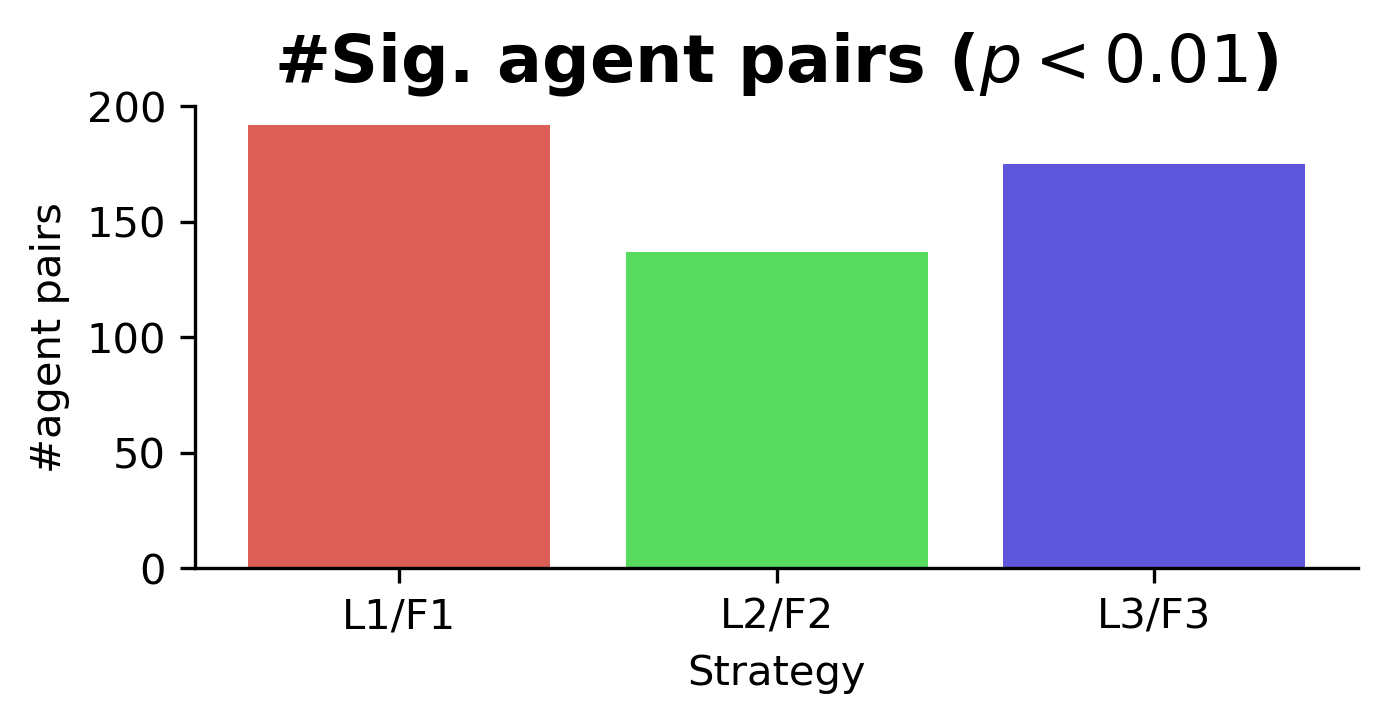

In [115]:
# (s1_btest< 0.01).sum(), (s2_btest< 0.01).sum(), (s3_btest< 0.01).sum()
# bar plot with that
fig, ax = plt.subplots(figsize=(5, 2), dpi=300)
ax.bar(["L1/F1", "L2/F2", "L3/F3"], [(s1_btest< 0.01).sum(), (s2_btest< 0.01).sum(), (s3_btest< 0.01).sum()], color=mycols)
ax.set_ylabel("#agent pairs")
ax.set_xlabel("Strategy")
ax.set_title("#Sig. agent pairs ($p<0.01$)", fontsize=16, weight='bold')
ax.set_ylim(0, 200)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig("training_significants.svg", format="svg")

## Training Stats

In [20]:
base= "../store_bk"
trains = sorted(os.listdir(base))

r0_train = []
r0_test = []
r1_train = []
r1_test = []

for i in tqdm(trains[:]):
    regime = 0
    ftest = f"{base}/{i}/logs/testing_{regime}.parquet"
    ftrain = f"{base}/{i}/logs/training_{regime}.parquet"
    
    tst = pd.read_parquet(ftest)
    r0_test.append(tst.r1.values)
    trn = pd.read_parquet(ftrain)
    r0_train.append(trn.r1.values)
    
    regime = 1
    ftest = f"{base}/{i}/logs/testing_{regime}.parquet"
    ftrain = f"{base}/{i}/logs/training_{regime}.parquet"
    tst = pd.read_parquet(ftest)
    r1_test.append(tst.r1.values)
    trn = pd.read_parquet(ftrain)
    r1_train.append(np.cumsum(trn.r1.values)[::100000])

r0_test = np.array(r0_test)
r0_train = np.array(r0_train)
r1_test = np.array(r1_test)
r1_train = np.array(r1_train)

r0_test = np.cumsum(r0_test, axis=1)
r0_train = np.cumsum(r0_train, axis=1)
r1_test = np.cumsum(r1_test, axis=1)

r0_test = r0_test[:, ::1000]
r0_train = r0_train[:, ::1000]
r1_test = r1_test[:, ::1000]
# r1_train = r1_train[:, ::1000]

r0_train.shape, r0_test.shape, r1_train.shape, r1_test.shape

100%|██████████| 200/200 [03:11<00:00,  1.05it/s]


((200, 1000), (200, 1000), (200, 500), (200, 1000))

In [17]:
np.arange(1_000_000)[::1000].shape

(1000,)

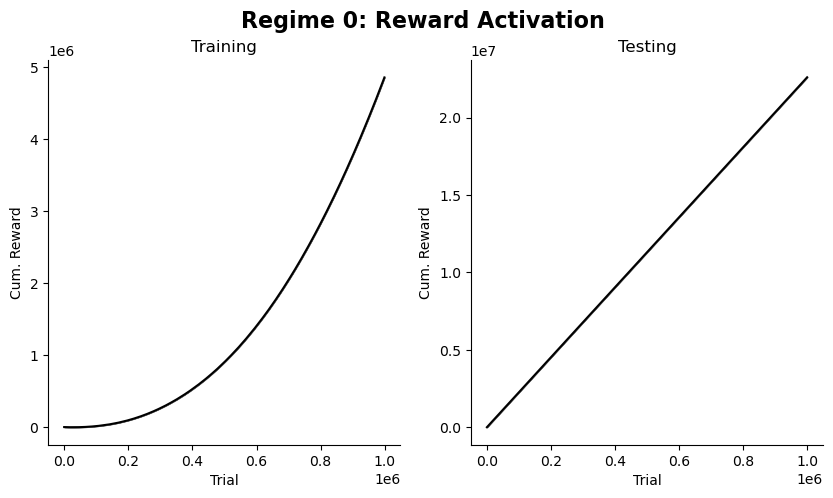

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=100)

r0_train_mean = r0_train.mean(axis=0)
r0_train_sem = r0_train.std(axis=0) / np.sqrt(r0_train.shape[0])

r0_test_mean = r0_test.mean(axis=0)
r0_test_sem = r0_test.std(axis=0) / np.sqrt(r0_test.shape[0])

# plot the mean and sem of the training and testing data
ax[0].plot(np.arange(1_000_000)[::1000], r0_train_mean, "k-", alpha=1)
ax[1].plot(np.arange(1_000_000)[::1000], r0_test_mean, "k-", alpha=1)

ax[0].fill_between(np.arange(1_000_000)[::1000], r0_train_mean - r0_train_sem, r0_train_mean + r0_train_sem, color="k", alpha=0.5)
ax[1].fill_between(np.arange(1_000_000)[::1000], r0_test_mean - r0_test_sem, r0_test_mean + r0_test_sem, color="k", alpha=0.5)

ax[0].set_title("Training")
ax[0].set_xlabel("Trial")
ax[0].set_ylabel("Cum. Reward")
# set top and right spines to invisible
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

ax[1].set_title("Testing")
ax[1].set_xlabel("Trial")
ax[1].set_ylabel("Cum. Reward")
# set top and right spines to invisible
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.suptitle("Regime 0: Reward Activation", fontsize=16, weight='bold')

plt.savefig("regime_0_cumsum.svg", format="svg")

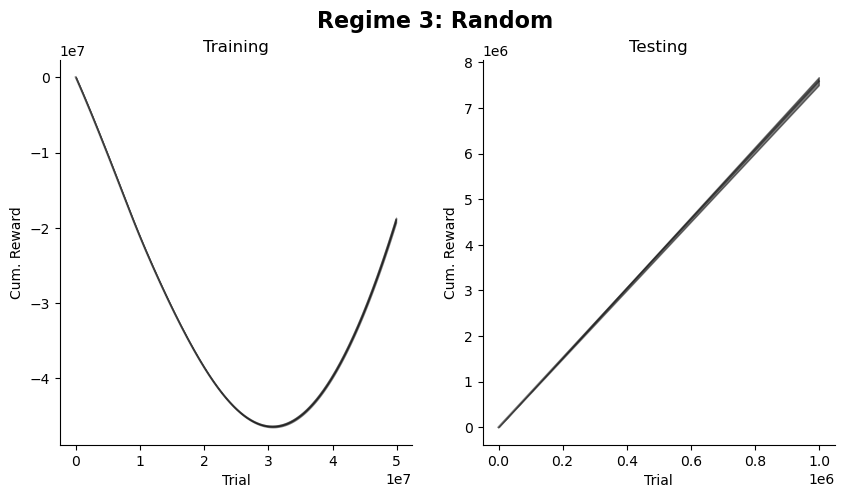

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=100)

r1_train_mean = r1_train.mean(axis=0)
r1_train_sem = r1_train.std(axis=0) / np.sqrt(r1_train.shape[0])

r1_test_mean = r1_test.mean(axis=0)
r1_test_sem = r1_test.std(axis=0) / np.sqrt(r1_test.shape[0])

ax[0].plot(np.arange(50_000_000)[::100000], r1_train_mean, "k-", alpha=.5)
ax[1].plot(np.arange(1_000_000)[::1000], r1_test_mean, "k-", alpha=.5)

ax[0].fill_between(np.arange(50_000_000)[::100000], r1_train_mean - r1_train_sem, r1_train_mean + r1_train_sem, color="k", alpha=0.5)
ax[1].fill_between(np.arange(1_000_000)[::1000], r1_test_mean - r1_test_sem, r1_test_mean + r1_test_sem, color="k", alpha=0.5)

ax[0].set_title("Training")
ax[0].set_xlabel("Trial")
ax[0].set_ylabel("Cum. Reward")
# set top and right spines to invisible
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

ax[1].set_title("Testing")
ax[1].set_xlabel("Trial")
ax[1].set_ylabel("Cum. Reward")
# set top and right spines to invisible
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)


plt.suptitle("Regime 3: Random", fontsize=16, weight='bold')
plt.savefig("regime_1_cumsum.svg", format="svg")

## Successful rzs

In [38]:
base= "../store_bk"
trains = sorted(os.listdir(base))

all_tdf = pd.DataFrame()

for i in tqdm(trains[:]):

    regime = 1
    ftest = f"{base}/{i}/trial_stats/testing_{regime}.parquet"
    tst = pd.read_parquet(ftest)
    tst["pair"] = i
    all_tdf = pd.concat([all_tdf, tst], ignore_index=True)


100%|██████████| 200/200 [01:19<00:00,  2.51it/s]


In [52]:
counts_series = all_tdf[all_tdf.collected == True].groupby("pair").reward_loc.value_counts()

In [54]:
df_counts = counts_series.unstack()
df_counts.head()

reward_loc,dl,rd,rl,ud,ul,ur
pair,,,,,,
0,13923,13992,13887,16225,15793,15883
1,15661,15507,15686,15549,15588,15607
10,15559,15472,15532,15467,15240,15372
100,15724,15685,15673,15578,15612,15671
101,14815,15546,15434,14883,14861,15413


In [55]:
mean_counts = df_counts.mean(axis=0)
sem_counts = df_counts.sem(axis=0)

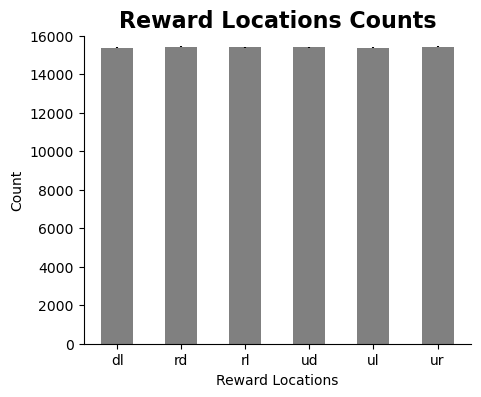

In [71]:
fig, ax = plt.subplots(figsize=(5, 4))
# bar with error bars
ax.bar(mean_counts.index, mean_counts.values, yerr=sem_counts.values, color="gray", width=0.5, alpha=1)
ax.set_ylabel("Count")
ax.set_xlabel("Reward Locations")
ax.set_title("Reward Locations Counts", fontsize=16, weight='bold')

# remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylim(0, 16_000)

plt.savefig("reward_locations_counts.svg", format="svg")

## Increasing freq of reward props

In [81]:
base= "../store_bk"
trains = sorted(os.listdir(base))

all_tdf = pd.DataFrame()

all_x = []
all_y = []

for i in tqdm(trains[:]):

    regime = 1
    ftest = f"{base}/{i}/trial_stats/training_{regime}.parquet"
    tst = pd.read_parquet(ftest)
    
    collection = tst.collected
    
    collection_bin = pd.cut(collection.index, bins=100)
    
    df = pd.DataFrame({'bin': collection_bin, 'value': collection.values})
    freq_df = df.groupby('bin', observed=True)['value'].mean().reset_index()
    freq_df['bin_center'] = [interval.mid for interval in freq_df['bin']]
    
    all_x.append(np.arange(100))
    all_y.append(freq_df.value)
    
    

100%|██████████| 200/200 [00:28<00:00,  7.10it/s]


In [73]:
all_tdf.head()

,trial_id,trial_length,activated,collected,wz_cancel,collected_zone,reward_loc,activated_by,activated_frame,first_close_to_zone,first_close_to_zone_frame,first_to_zone,first_to_zone_frame,reward_counter,pair
0,0,18,True,True,False,u,ul,a2,5.0,a2,10.0,a2,16.0,82,0
1,1,14,True,True,False,u,ur,a1,2.0,a1,23.0,a1,26.0,86,0
2,2,8,True,True,False,u,ud,a2,1.0,a2,36.0,a2,38.0,92,0
3,3,10,True,True,False,d,ud,a2,0.0,a2,43.0,a2,46.0,90,0
4,4,11,True,True,False,d,rd,a1,1.0,a1,54.0,a1,56.0,89,0


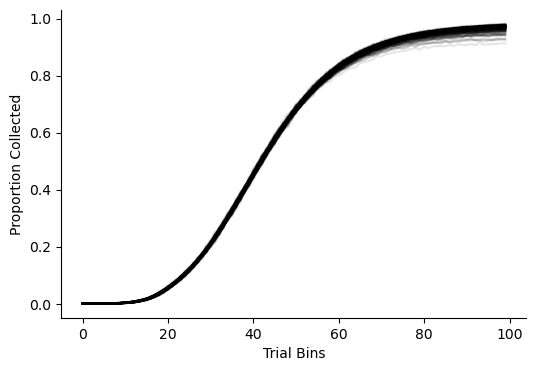

In [90]:
fig, ax = plt.subplots(figsize=(6, 4))

for i in range(200):
    ax.plot(all_x[i], all_y[i], "k-", alpha=0.1)

ax.set_xlabel("Trial Bins")
ax.set_ylabel("Proportion Collected")

# remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("training_success.svg", format="svg")

## Path

In [117]:
store = f"../store_bk/1/logs/testing_1.parquet"
df = pd.read_parquet(store)
df["trial_id"] = df.terminated.cumsum().shift(fill_value=0)
df.head()

,regime_idx,frame_idx,reward_loc,activated,collected,terminated,steps_without_reward,a1x,a1y,a2x,a2y,r1,r2,trial_id
0,1,0,None,False,False,False,17,7,4,2,5,-1,-1,0
1,1,1,None,False,False,False,18,7,5,2,5,-1,-1,0
2,1,2,None,False,False,False,19,6,5,2,5,-1,-1,0
3,1,3,ul,True,False,False,20,5,5,2,4,-1,-1,0
4,1,4,ul,False,False,False,21,4,5,1,4,-1,-1,0


In [118]:
locs = df[df.trial_id == 0][["a1x", "a1y", "a2x", "a2y"]].values
locs.shape

(9, 4)

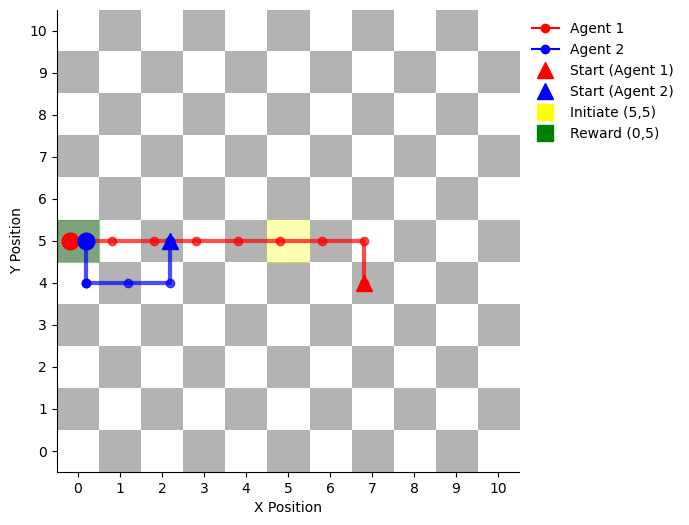

In [159]:
positions = locs

# Extract the trajectories for each agent.
a1x, a1y = positions[:, 0], positions[:, 1]
a2x, a2y = positions[:, 2], positions[:, 3]

# Convert cell indices to cell centers by adding 0.5.
# Also add a fixed horizontal offset so that when both agents are in the same cell they do not overlap.
offset = 0.2  # amount to offset horizontally
a1x_center = a1x + 0.5 - offset  # Agent 1 (red) slightly left
a1y_center = a1y + 0.5
a2x_center = a2x + 0.5 + offset  # Agent 2 (blue) slightly right
a2y_center = a2y + 0.5

# Create a checkerboard pattern for the grid cells
grid_size = 11
# Create an array where cells alternate (0 and 1) for the checkerboard pattern
checkerboard = (np.indices((grid_size, grid_size)).sum(axis=0)) % 2

# Set up the plot.
fig, ax = plt.subplots(figsize=(6, 6))

# Display the grid as an image.
# Using 'binary' colormap (or 'gray') produces a black-and-white effect.
# Set interpolation='none' so that each cell is clearly visible.
ax.imshow(checkerboard, extent=[0, grid_size, 0, grid_size], cmap='binary', origin='lower', interpolation='none', alpha=0.3)

# Color the 5,5 cell in yellow
ax.add_patch(plt.Rectangle((5, 5), 1, 1, color='yellow', alpha=0.3))

# Color the 0,5 cell in green 
ax.add_patch(plt.Rectangle((0, 5), 1, 1, color='green', alpha=0.3))

# Plot Agent 1 trajectory (red)
ax.plot(a1x_center, a1y_center, color='red', marker='o', linestyle='-', markersize=6, label='Agent 1', linewidth=3, alpha=0.7)
# Mark the starting position with a triangle and ending with a larger dot for Agent 1
ax.plot(a1x_center[0], a1y_center[0], color='red', marker='^', markersize=12)  # Start marker
ax.plot(a1x_center[-1], a1y_center[-1], color='red', marker='o', markersize=12)  # End marker

# Plot Agent 2 trajectory (blue)
ax.plot(a2x_center, a2y_center, color='blue', marker='o', linestyle='-', markersize=6, label='Agent 2', linewidth=3, alpha=0.7)
# Mark the starting position with a triangle and ending with a larger dot for Agent 2
ax.plot(a2x_center[0], a2y_center[0], color='blue', marker='^', markersize=12)  # Start marker
ax.plot(a2x_center[-1], a2y_center[-1], color='blue', marker='o', markersize=12)  # End marker

# Set the axis limits to cover the entire grid area.
ax.set_xlim(0, grid_size)
ax.set_ylim(0, grid_size)
ax.set_aspect('equal')

# set the x and y ticks to be the cell centers
ax.set_xticks(np.arange(0.5, grid_size, 1))
ax.set_yticks(np.arange(0.5, grid_size, 1))
ax.set_xticklabels(np.arange(0, grid_size))
ax.set_yticklabels(np.arange(0, grid_size))

# Add labels and title.
ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")

# remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# along with the agent 1 and agent 2, legend should have start and end markers as well as the yellow and green cells
legend_elements = [
    plt.Line2D([0], [0], color='red', marker='o', linestyle='-', markersize=6, label='Agent 1'),
    plt.Line2D([0], [0], color='blue', marker='o', linestyle='-', markersize=6, label='Agent 2'),
    plt.Line2D([0], [0], color='red', marker='^', markersize=12, label='Start (Agent 1)', linestyle='None'),
    plt.Line2D([0], [0], color='blue', marker='^', markersize=12, label='Start (Agent 2)', linestyle='None'),
    plt.Line2D([0], [0], color='yellow', marker='s', markersize=12, label='Initiate (5,5)', linestyle='None'),
    plt.Line2D([0], [0], color='green', marker='s', markersize=12, label='Reward (0,5)', linestyle='None')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, frameon=False, bbox_to_anchor=(1, 1))

plt.savefig("agent_trajectories.svg", format="svg", bbox_inches='tight')

## Persistance

In [150]:

base= "../store_bk"
trains = sorted(os.listdir(base))

ss1 = []
ss2 = []
ss3 = []

train_tt = []

for i in tqdm(trains[:]):
    f = f"{base}/{i}/trial_stats/training_1.parquet"
    t = pd.read_parquet(f)
    train_tt.append(t.trial_id.max())
    ss1.append(t.activated_by.value_counts().to_dict())
    ss2.append(t.first_close_to_zone.value_counts().to_dict())
    ss3.append(t.first_to_zone.value_counts().to_dict())

100%|██████████| 200/200 [00:37<00:00,  5.32it/s]


In [151]:
strat_1 = ss1
strat_2 = ss2
strat_3 = ss3

In [152]:
l1 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_1]
f1 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_1]

l2 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_2]
f2 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_2]

l3 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_3]
f3 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_3]

# renamed mouse list
mst1 = []
mst2 = []
mst3 = []

for i in leader_index:
    mst1.append({ "a1": strat_1[i][l1[i]], "a2": strat_1[i][f1[i]] })
    mst2.append({ "a1": strat_2[i][l1[i]], "a2": strat_2[i][f1[i]] })
    mst3.append({ "a1": strat_3[i][l1[i]], "a2": strat_3[i][f1[i]] })
for j in follower_index:
    mst1.append({ "a1": strat_1[j][f1[j]], "a2": strat_1[j][l1[j]] })
    mst2.append({ "a1": strat_2[j][f1[j]], "a2": strat_2[j][l1[j]] })
    mst3.append({ "a1": strat_3[j][f1[j]], "a2": strat_3[j][l1[j]] })
    
strat_1 = mst1
strat_2 = mst2
strat_3 = mst3

In [153]:
cols = ["a1", "a2", "tie"]
st_1 = pd.DataFrame(strat_1, columns=cols)
st_2 = pd.DataFrame(strat_2, columns=cols)
st_3 = pd.DataFrame(strat_3, columns=cols)

st_1 = st_1.fillna(0).astype(int)
st_2 = st_2.fillna(0).astype(int)
st_3 = st_3.fillna(0).astype(int)

s1_btest = pd.Series(do_btest(st_1), name="pval")
s2_btest = pd.Series(do_btest(st_2), name="pval")
s3_btest = pd.Series(do_btest(st_3), name="pval")

In [154]:
# s1_btest < 0.01
sig_strat_1 = [strat_1[i] for i in range(200) if s1_btest[i] < 0.01]
sig_strat_2 = [strat_2[i] for i in range(200) if s2_btest[i] < 0.01]
sig_strat_3 = [strat_3[i] for i in range(200) if s3_btest[i] < 0.01]

strat_1 = sig_strat_1
strat_2 = sig_strat_2
strat_3 = sig_strat_3

In [155]:
l1 = np.array([ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_1])
f1 = np.array([ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_1])

l2 = np.array([ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_2])
f2 = np.array([ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_2])

l3 = np.array([ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_3])
f3 = np.array([ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_3])

l1_data = {
    'L1': [strat_1[i][l]/train_tt[i] for i, l in enumerate(l1)],
    'F1': [strat_1[i][l]/train_tt[i] for i, l in enumerate(f1)],
}

l2_data = {
    'L2': [strat_2[i][l]/train_tt[i] for i, l in enumerate(l2)],
    'F2': [strat_2[i][l]/train_tt[i] for i, l in enumerate(f2)],
}

l3_data = {
    'L3': [strat_3[i][l]/train_tt[i] for i, l in enumerate(l3)],
    'F3': [strat_3[i][l]/train_tt[i] for i, l in enumerate(f3)],
}

# l1_data = {
#     'L1': [strat_1[i][l]/(strat_1[i]["a1"] + strat_1[i]["a2"]) for i, l in enumerate(l1)],
#     'F1': [strat_1[i][l]/(strat_1[i]["a1"] + strat_1[i]["a2"]) for i, l in enumerate(f1)],
# }

# l2_data = {
#     'L2': [strat_2[i][l]/(strat_2[i]["a1"] + strat_2[i]["a2"]) for i, l in enumerate(l2)],
#     'F2': [strat_2[i][l]/(strat_2[i]["a1"] + strat_2[i]["a2"]) for i, l in enumerate(f2)],
# }

# l3_data = {
#     'L3': [strat_3[i][l]/(strat_3[i]["a1"] + strat_3[i]["a2"]) for i, l in enumerate(l3)],
#     'F3': [strat_3[i][l]/(strat_3[i]["a1"] + strat_3[i]["a2"]) for i, l in enumerate(f3)],
# }

In [156]:
len(l1_data["L1"]), len(l2_data["L2"]), len(l3_data["L3"])

(192, 137, 175)

In [157]:
train_data = (l1_data, l2_data, l3_data)

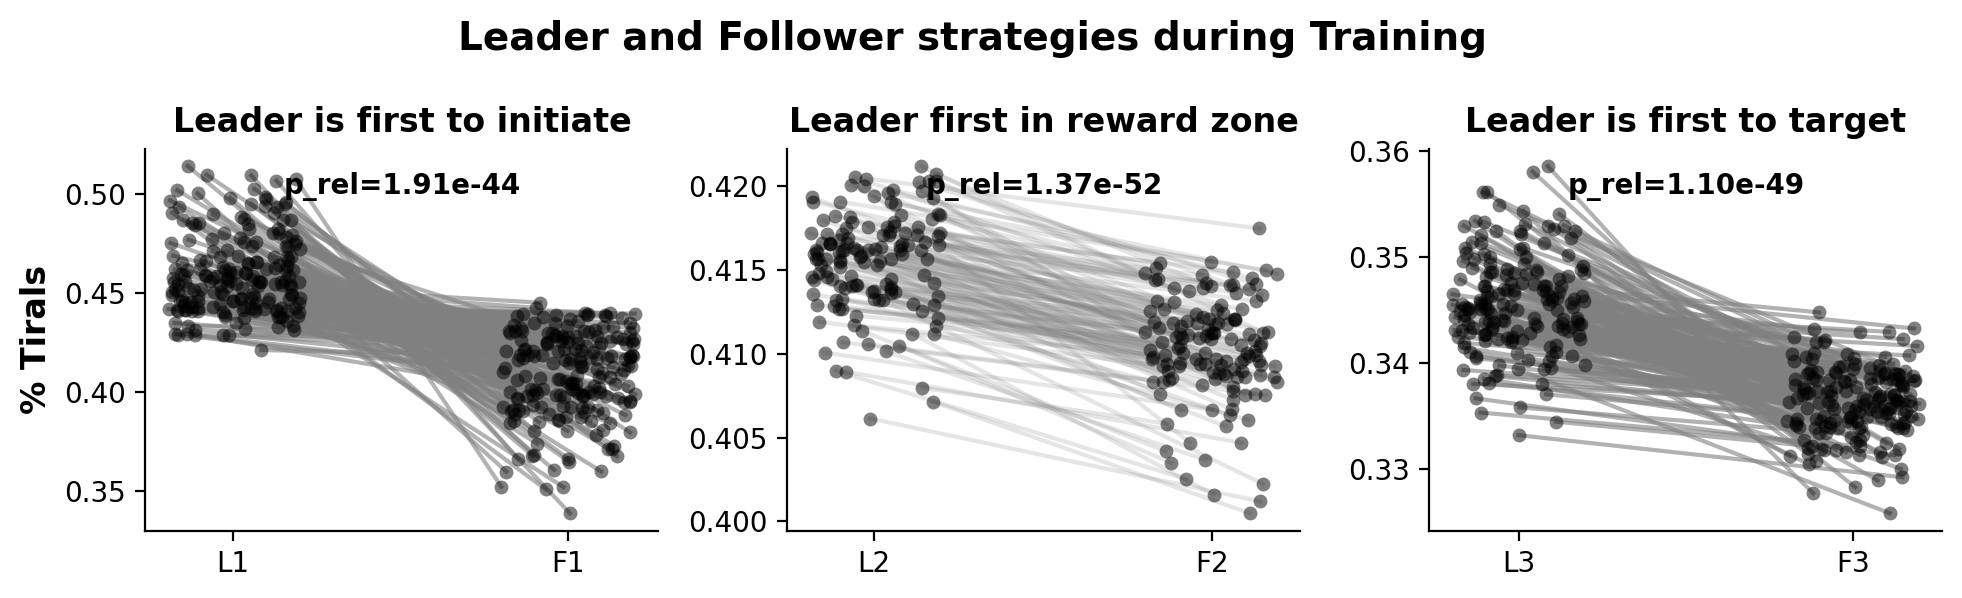

In [158]:
# Plotting the leaders and followers aligned
fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharey=False, dpi=200)

ax = sns.stripplot(data=l1_data, ax=axs[0], jitter=0.2, alpha=0.5, color="black")
offsets = {}
for collection, category in zip(ax.collections, ["L1", "F1"]):
    offsets[category] = np.array(collection.get_offsets())

# Draw connecting lines
for i in range(len(l1)):
    x1, y1 = offsets["L1"][i]
    x2, y2 = offsets["F1"][i]
    axs[0].plot([x1, x2], [y1, y2], color='gray', linestyle='-', alpha=0.6)

pt = ttest_rel(l1_data['L1'], l1_data['F1']).pvalue
pmw = mannwhitneyu(l1_data['L1'], l1_data['F1']).pvalue
axs[0].text(0.5, 0.9, f"p_rel={pt:.2e}", horizontalalignment='center', verticalalignment='center', transform=axs[0].transAxes, fontsize=10, fontweight='bold')

axs[0].set_title('Leader is first to initiate', fontsize=12, fontweight='bold')

ax = sns.stripplot(data=l2_data, ax=axs[1], jitter=0.2, alpha=0.5, color="black")
offsets = {}
for collection, category in zip(ax.collections, ["L2", "F2"]):
    offsets[category] = np.array(collection.get_offsets())

# Draw connecting lines
for i in range(len(l2)):
    x1, y1 = offsets["L2"][i]
    x2, y2 = offsets["F2"][i]
    axs[1].plot([x1, x2], [y1, y2], color='gray', linestyle='-', alpha=0.2)

pt = ttest_rel(l2_data['L2'], l2_data['F2']).pvalue
pmw = mannwhitneyu(l2_data['L2'], l2_data['F2']).pvalue
axs[1].text(0.5, 0.9, f"p_rel={pt:.2e}", horizontalalignment='center', verticalalignment='center', transform=axs[1].transAxes, fontsize=10, fontweight='bold')
axs[1].set_title('Leader first in reward zone', fontsize=12, fontweight='bold')

ax = sns.stripplot(data=l3_data, ax=axs[2], jitter=0.2, alpha=0.5, color="black")
offsets = {}
for collection, category in zip(ax.collections, ["L3", "F3"]):
    offsets[category] = np.array(collection.get_offsets())

# Draw connecting lines
for i in range(len(l3)):
    x1, y1 = offsets["L3"][i]
    x2, y2 = offsets["F3"][i]
    axs[2].plot([x1, x2], [y1, y2], color='gray', linestyle='-', alpha=0.6)

pt = ttest_rel(l3_data['L3'], l3_data['F3']).pvalue
pmw = mannwhitneyu(l3_data['L3'], l3_data['F3']).pvalue
axs[2].text(0.5, 0.9, f"p_rel={pt:.2e}", horizontalalignment='center', verticalalignment='center', transform=axs[2].transAxes, fontsize=10, fontweight='bold')
axs[2].set_title('Leader is first to target', fontsize=12, fontweight='bold')
axs[0].set_ylabel('% Tirals', fontsize=12, fontweight='bold')

plt.suptitle('Leader and Follower strategies during Training', fontsize=14, fontweight='bold')

# remove all the top and right spines
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("training_leader_followers.svg", format="svg")

In [159]:

base= "../store_bk"
trains = sorted(os.listdir(base))

strat_1 = []
strat_2 = []
strat_3 = []

eval_tt = []

for i in tqdm(trains[:]):
    f = f"{base}/{i}/trial_stats/testing_1.parquet"
    t = pd.read_parquet(f)
    eval_tt.append(t.trial_id.max())
    strat_1.append(t.activated_by.value_counts().to_dict())
    strat_2.append(t.first_close_to_zone.value_counts().to_dict())
    strat_3.append(t.first_to_zone.value_counts().to_dict())

100%|██████████| 200/200 [00:04<00:00, 48.21it/s]


In [160]:
sig_strat_1 = [strat_1[i] for i in range(200) if s1_btest[i] < 0.01]
sig_strat_2 = [strat_2[i] for i in range(200) if s2_btest[i] < 0.01]
sig_strat_3 = [strat_3[i] for i in range(200) if s3_btest[i] < 0.01]

strat_1 = sig_strat_1
strat_2 = sig_strat_2
strat_3 = sig_strat_3

In [161]:

es1_l1 = [ strat_1[i][leader] / eval_tt[i] for i, leader in enumerate(l1)]
es1_f1 = [ strat_1[i][follower] / eval_tt[i] for i, follower in enumerate(f1)]

es1_l2 = [ strat_2[i][leader] / eval_tt[i] for i, leader in enumerate(l2)]
es1_f2 = [ strat_2[i][follower] / eval_tt[i] for i, follower in enumerate(f2)]

es1_l3 = [ strat_3[i][leader] / eval_tt[i] for i, leader in enumerate(l3)]
es1_f3 = [ strat_3[i][follower] / eval_tt[i] for i, follower in enumerate(f3)]

# es1_l1 = [ strat_1[i][leader] / (strat_1[i]["a1"]+ strat_1[i]["a2"]) for i, leader in enumerate(l1)]
# es1_f1 = [ strat_1[i][follower] / (strat_1[i]["a1"]+ strat_1[i]["a2"]) for i, follower in enumerate(f1)]

# es1_l2 = [ strat_2[i][leader] / (strat_2[i]["a1"]+ strat_2[i]["a2"]) for i, leader in enumerate(l2)]
# es1_f2 = [ strat_2[i][follower] / (strat_2[i]["a1"]+ strat_2[i]["a2"]) for i, follower in enumerate(f2)]

# es1_l3 = [ strat_3[i][leader] / (strat_3[i]["a1"]+ strat_3[i]["a2"]) for i, leader in enumerate(l3)]
# es1_f3 = [ strat_3[i][follower] / (strat_3[i]["a1"]+ strat_3[i]["a2"]) for i, follower in enumerate(f3)]


In [162]:

# getting the leader 1
l1_data = {
    'L1': es1_l1,
    'F1': es1_f1,
}

l2_data = {
    'L2': es1_l2,
    'F2': es1_f2,
}

l3_data = {
    'L3': es1_l3,
    'F3': es1_f3,
}


In [163]:
len(l1_data["L1"]), len(l2_data["L2"]), len(l3_data["L3"])

(192, 137, 175)

In [164]:
test_data = (l1_data, l2_data, l3_data)

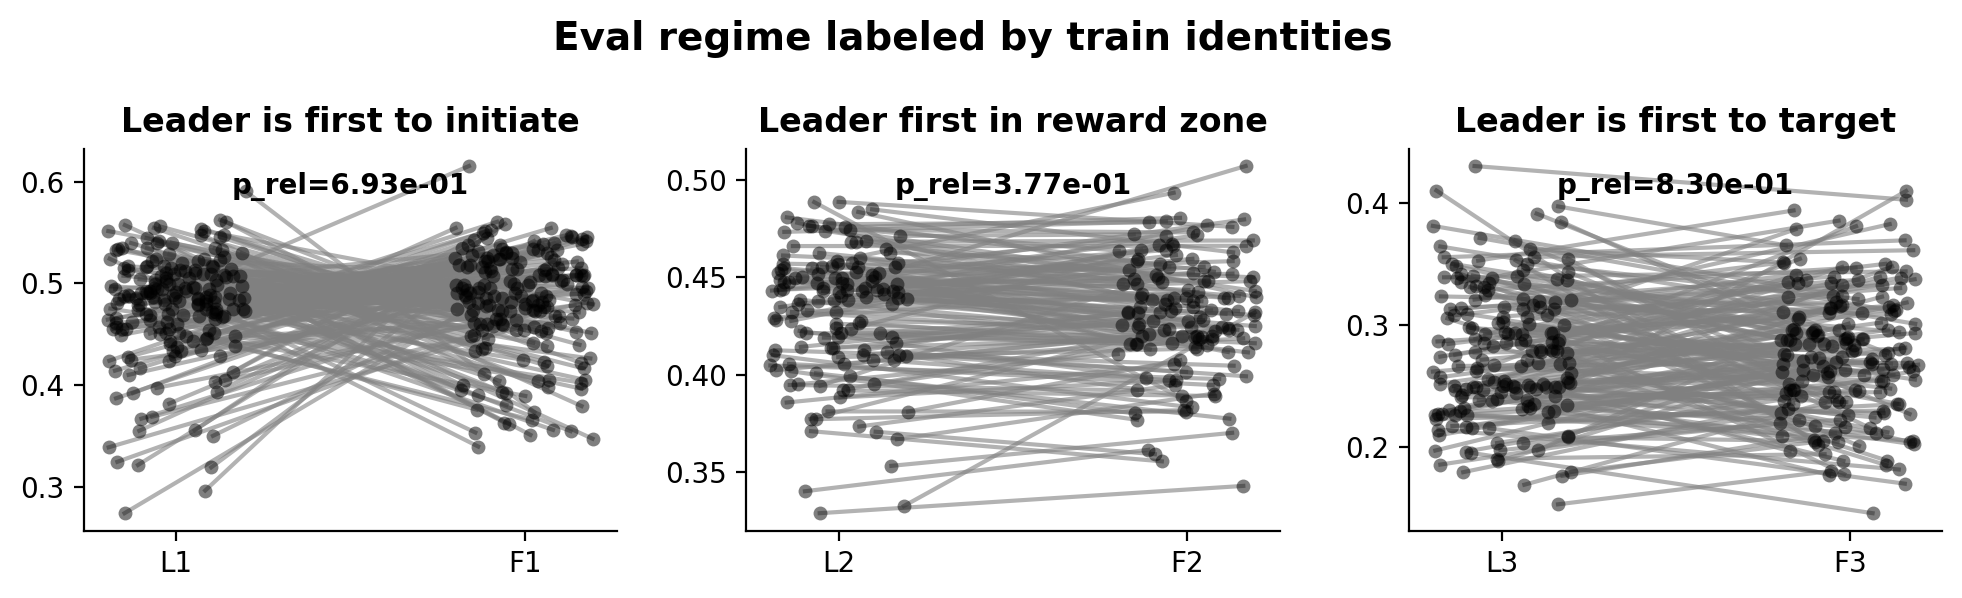

In [165]:
# Plotting the leaders and followers aligned
fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharey=False, dpi=200)


#########################################
ax = sns.stripplot(data=l1_data, ax=axs[0], jitter=0.2, alpha=0.5, color="black")
offsets = {}
for collection, category in zip(ax.collections, ["L1", "F1"]):
    offsets[category] = np.array(collection.get_offsets())
for i in range(len(l1)):
    x1, y1 = offsets["L1"][i]
    x2, y2 = offsets["F1"][i]
    axs[0].plot([x1, x2], [y1, y2], color='gray', linestyle='-', alpha=0.6)
pin = ttest_rel(l1_data['L1'], l1_data['F1']).pvalue
pmw = mannwhitneyu(l1_data['L1'], l1_data['F1']).pvalue
axs[0].text(0.5, 0.9, f"p_rel={pin:.2e}", horizontalalignment='center', verticalalignment='center', transform=axs[0].transAxes, fontsize=10, fontweight='bold')
axs[0].set_title('Leader is first to initiate', fontsize=12, fontweight='bold')

#########################################
ax = sns.stripplot(data=l2_data, ax=axs[1], jitter=0.2, alpha=0.5, color="black")
offsets = {}
for collection, category in zip(ax.collections, ["L2", "F2"]):
    offsets[category] = np.array(collection.get_offsets())
for i in range(len(l2)):
    x1, y1 = offsets["L2"][i]
    x2, y2 = offsets["F2"][i]
    axs[1].plot([x1, x2], [y1, y2], color='gray', linestyle='-', alpha=0.6)
pin = ttest_rel(l2_data['L2'], l2_data['F2']).pvalue
pmw = mannwhitneyu(l2_data['L2'], l2_data['F2']).pvalue
axs[1].text(0.5, 0.9, f"p_rel={pin:.2e}", horizontalalignment='center', verticalalignment='center', transform=axs[1].transAxes, fontsize=10, fontweight='bold')
axs[1].set_title('Leader first in reward zone', fontsize=12, fontweight='bold')

#########################################
ax = sns.stripplot(data=l3_data, ax=axs[2], jitter=0.2, alpha=0.5, color="black")
offsets = {}
for collection, category in zip(ax.collections, ["L3", "F3"]):
    offsets[category] = np.array(collection.get_offsets())
for i in range(len(l3)):
    x1, y1 = offsets["L3"][i]
    x2, y2 = offsets["F3"][i]
    axs[2].plot([x1, x2], [y1, y2], color='gray', linestyle='-', alpha=0.6)
pin = ttest_rel(l3_data['L3'], l3_data['F3']).pvalue
pmw = mannwhitneyu(l3_data['L3'], l3_data['F3']).pvalue
axs[2].text(0.5, 0.9, f"p_rel={pin:.2e}", horizontalalignment='center', verticalalignment='center', transform=axs[2].transAxes, fontsize=10, fontweight='bold')
axs[2].set_title('Leader is first to target', fontsize=12, fontweight='bold')

#########################################
plt.suptitle("Eval regime labeled by train identities", fontsize=14, fontweight='bold')

# remove all the top and right spines
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig("testing_leader_followers.svg", format="svg")

### Pvals

In [122]:
td1, td2, td3 = train_data
ed1, ed2, ed3 = test_data

In [123]:
ttest_rel(td1["L1"], ed1["L1"]).pvalue

np.float64(1.313289101705674e-13)

In [124]:
ttest_rel(td2["L2"], ed2["L2"]).pvalue

np.float64(0.05999821293875587)

In [125]:
ttest_rel(td3["L3"], ed3["L3"]).pvalue

np.float64(0.11886708030856356)

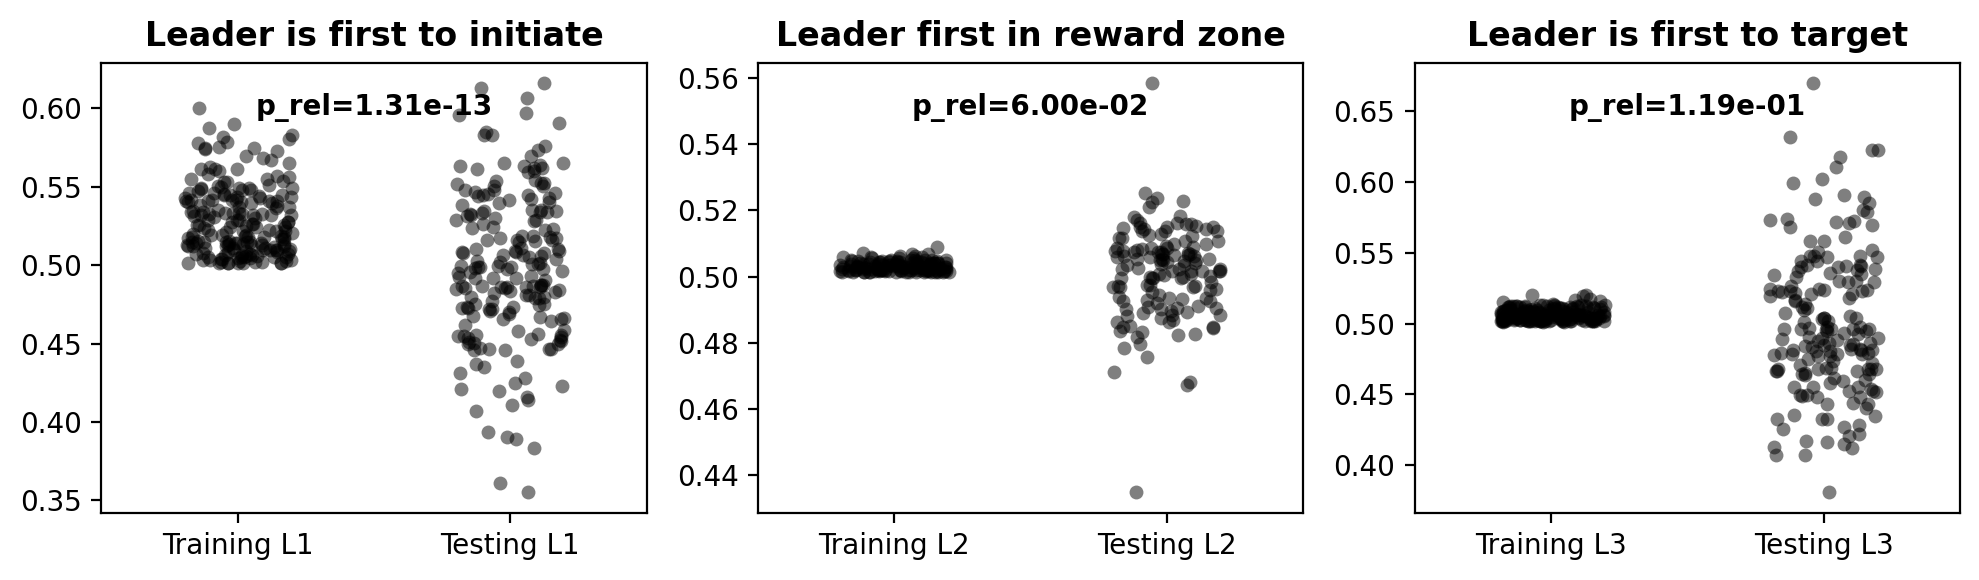

In [127]:
# Make the stripplot for these pairs now

fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharey=False, dpi=200)

ax = sns.stripplot(data=[td1["L1"], ed1["L1"]], ax=axs[0], jitter=0.2, alpha=0.5, color="black")
# give xticks as Training L1 and Testing L1
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(["Training L1", "Testing L1"])

ax = sns.stripplot(data=[td2["L2"], ed2["L2"]], ax=axs[1], jitter=0.2, alpha=0.5, color="black")
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(["Training L2", "Testing L2"])

ax = sns.stripplot(data=[td3["L3"], ed3["L3"]], ax=axs[2], jitter=0.2, alpha=0.5, color="black")
axs[2].set_xticks([0, 1])
axs[2].set_xticklabels(["Training L3", "Testing L3"])

# now put the pvalues on the plots
pt = ttest_rel(td1["L1"], ed1["L1"]).pvalue
axs[0].text(0.5, 0.9, f"p_rel={pt:.2e}", horizontalalignment='center', verticalalignment='center', transform=axs[0].transAxes, fontsize=10, fontweight='bold')
pt = ttest_rel(td2["L2"], ed2["L2"]).pvalue
axs[1].text(0.5, 0.9, f"p_rel={pt:.2e}", horizontalalignment='center', verticalalignment='center', transform=axs[1].transAxes, fontsize=10, fontweight='bold')
pt = ttest_rel(td3["L3"], ed3["L3"]).pvalue
axs[2].text(0.5, 0.9, f"p_rel={pt:.2e}", horizontalalignment='center', verticalalignment='center', transform=axs[2].transAxes, fontsize=10, fontweight='bold')

axs[0].set_title('Leader is first to initiate', fontsize=12, fontweight='bold')
axs[1].set_title('Leader first in reward zone', fontsize=12, fontweight='bold')
axs[2].set_title('Leader is first to target', fontsize=12, fontweight='bold')

plt.tight_layout()

plt.savefig("leader_persistance.svg", format="svg")

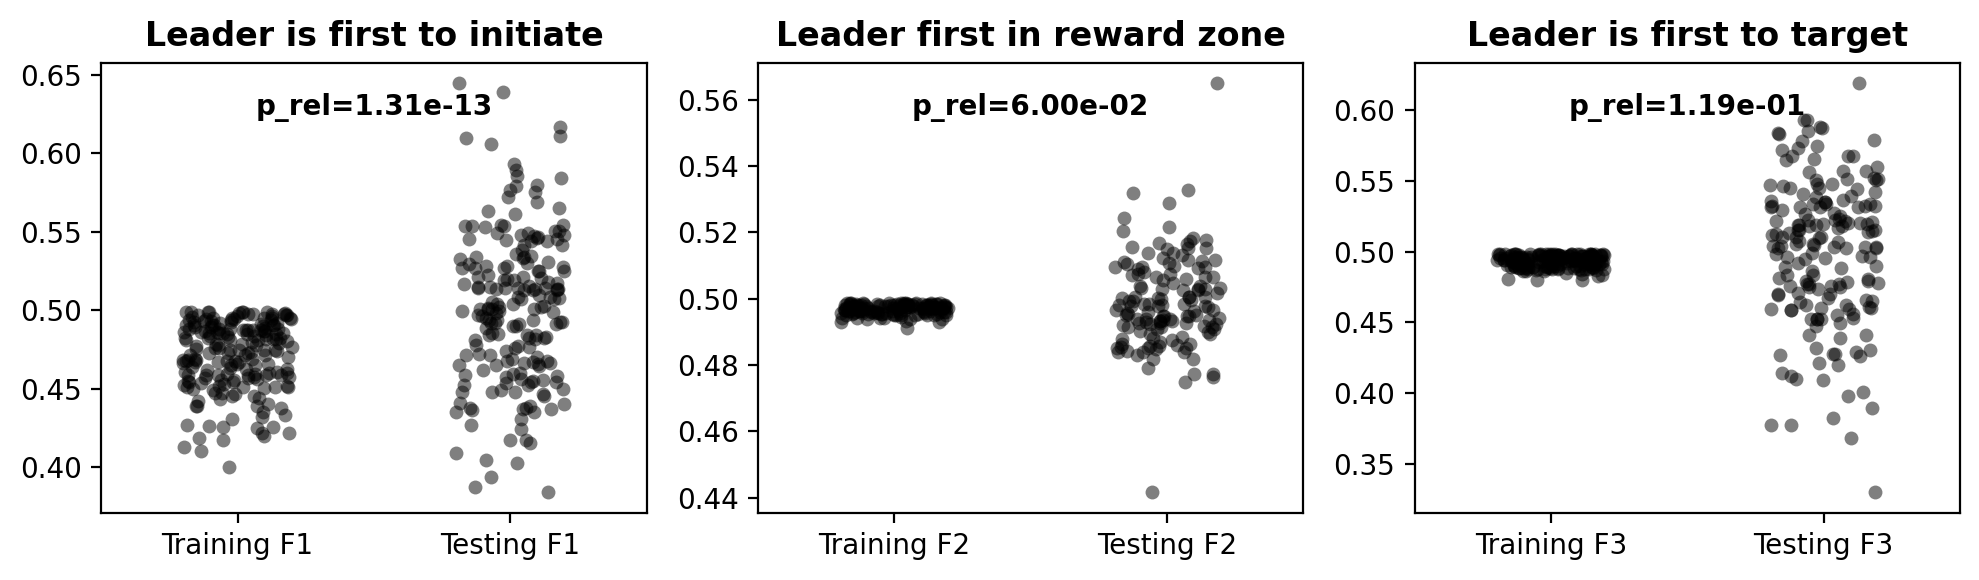

In [128]:
# Make the stripplot for these pairs now

fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharey=False, dpi=200)

ax = sns.stripplot(data=[td1["F1"], ed1["F1"]], ax=axs[0], jitter=0.2, alpha=0.5, color="black")
# give xticks as Training F1 and Testing F1
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(["Training F1", "Testing F1"])

ax = sns.stripplot(data=[td2["F2"], ed2["F2"]], ax=axs[1], jitter=0.2, alpha=0.5, color="black")
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(["Training F2", "Testing F2"])

ax = sns.stripplot(data=[td3["F3"], ed3["F3"]], ax=axs[2], jitter=0.2, alpha=0.5, color="black")
axs[2].set_xticks([0, 1])
axs[2].set_xticklabels(["Training F3", "Testing F3"])

# now put the pvalues on the plots
pt = ttest_rel(td1["F1"], ed1["F1"]).pvalue
axs[0].text(0.5, 0.9, f"p_rel={pt:.2e}", horizontalalignment='center', verticalalignment='center', transform=axs[0].transAxes, fontsize=10, fontweight='bold')
pt = ttest_rel(td2["F2"], ed2["F2"]).pvalue
axs[1].text(0.5, 0.9, f"p_rel={pt:.2e}", horizontalalignment='center', verticalalignment='center', transform=axs[1].transAxes, fontsize=10, fontweight='bold')
pt = ttest_rel(td3["F3"], ed3["F3"]).pvalue
axs[2].text(0.5, 0.9, f"p_rel={pt:.2e}", horizontalalignment='center', verticalalignment='center', transform=axs[2].transAxes, fontsize=10, fontweight='bold')

axs[0].set_title('Leader is first to initiate', fontsize=12, fontweight='bold')
axs[1].set_title('Leader first in reward zone', fontsize=12, fontweight='bold')
axs[2].set_title('Leader is first to target', fontsize=12, fontweight='bold')

plt.tight_layout()

plt.savefig("follower_persistance.svg", format="svg")

# Behav Paths

In [6]:
# Predefined lookup and type dictionary
grid = (11,11)
reward_place_to_coord = {
    "u": ((grid[0] // 2, grid[1] - 1),),
    "r": ((grid[0] - 1, grid[1] // 2),),
    "d": ((grid[0] // 2, 0),),
    "l": ((0, grid[1] // 2),),
    "ur": ((grid[0] // 2, grid[1] - 1), (grid[0] - 1, grid[1] // 2)),
    "rd": ((grid[0] - 1, grid[1] // 2), (grid[0] // 2, 0)),
    "dl": ((grid[0] // 2, 0), (0, grid[1] // 2)),
    "ul": ((0, grid[1] // 2), (grid[0] // 2, grid[1] - 1)),
    "ud": ((grid[0] // 2, grid[1] - 1), (grid[0] // 2, 0)),
    "rl": ((grid[0] - 1, grid[1] // 2), (0, grid[1] // 2)),
    # Note: Replace this with the updated one
}        # Mapping from reward identifiers to board coordinates.


In [7]:
def get_reward_coord(zone):
    """Return the first coordinate tuple from the lookup, or (None, None) if not found."""
    if zone in reward_place_to_coord and reward_place_to_coord[zone]:
        return reward_place_to_coord[zone][0]
    else:
        return (None, None)

In [8]:

base= "../store_bk"
trains = sorted(os.listdir(base))

strat_1 = []
strat_2 = []
strat_3 = []

train_tt = []

for i in tqdm(trains[:]):
    f = f"{base}/{i}/trial_stats/testing_1.parquet"
    t = pd.read_parquet(f)
    train_tt.append(t.trial_id.max())
    strat_1.append(t.activated_by.value_counts().to_dict())
    strat_2.append(t.first_close_to_zone.value_counts().to_dict())
    strat_3.append(t.first_to_zone.value_counts().to_dict())

100%|██████████| 200/200 [00:04<00:00, 46.08it/s]


In [9]:
l1 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_1]
f1 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_1]

l2 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_2]
f2 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_2]

l3 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_3]
f3 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_3]

# renamed mouse list
mst1 = []
mst2 = []
mst3 = []

for i in leader_index:
    mst1.append({ "a1": strat_1[i][l1[i]], "a2": strat_1[i][f1[i]] })
    mst2.append({ "a1": strat_2[i][l1[i]], "a2": strat_2[i][f1[i]] })
    mst3.append({ "a1": strat_3[i][l1[i]], "a2": strat_3[i][f1[i]] })
for j in follower_index:
    mst1.append({ "a1": strat_1[j][f1[j]], "a2": strat_1[j][l1[j]] })
    mst2.append({ "a1": strat_2[j][f1[j]], "a2": strat_2[j][l1[j]] })
    mst3.append({ "a1": strat_3[j][f1[j]], "a2": strat_3[j][l1[j]] })
    
strat_1 = mst1
strat_2 = mst2
strat_3 = mst3

In [10]:
test_strats = (strat_1, strat_2, strat_3)

cols = ["a1", "a2", "tie"]
strat_1 = pd.DataFrame(strat_1, columns=cols)
strat_2 = pd.DataFrame(strat_2, columns=cols)
strat_3 = pd.DataFrame(strat_3, columns=cols)

strat_1 = strat_1.fillna(0).astype(int)
strat_2 = strat_2.fillna(0).astype(int)
strat_3 = strat_3.fillna(0).astype(int)

s1_btest = pd.Series(do_btest(strat_1), name="pval")
s2_btest = pd.Series(do_btest(strat_2), name="pval")
s3_btest = pd.Series(do_btest(strat_3), name="pval")

l1 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_1.to_dict(orient="records")]
f1 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_1.to_dict(orient="records")]

l2 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_2.to_dict(orient="records")]
f2 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_2.to_dict(orient="records")]

l3 = [ "a1" if e["a1"] > e["a2"] else "a2" for e in strat_3.to_dict(orient="records")]
f3 = [ "a1" if e["a1"] < e["a2"] else "a2" for e in strat_3.to_dict(orient="records")]

test_sig = pd.DataFrame({
    "l1": [ strat_1.iloc[i][l1[i]] for i in range(len(l1))],
    "f1": [ strat_1.iloc[i][f1[i]] for i in range(len(f1))],
    "s1": s1_btest,
    "l2": [ strat_2.iloc[i][l2[i]] for i in range(len(l2))],
    "f2": [ strat_2.iloc[i][f2[i]] for i in range(len(f2))],
    "s2": s2_btest,
    "l3": [ strat_3.iloc[i][l3[i]] for i in range(len(l3))],
    "f3": [ strat_3.iloc[i][f3[i]] for i in range(len(f3))],
    "s3": s3_btest,
})

In [11]:
# regime = 1
# all_tdf = pd.DataFrame()

# for pairs in tqdm(range(100)):
#     store = f"../store_bk/{pairs}/logs/"
#     stats = f"../store_bk/{pairs}/trial_stats/"
#     edf = pd.read_parquet(f'{store}testing_{regime}.parquet')
#     sdf = pd.read_parquet(f'{stats}testing_{regime}.parquet')
#     edf["trial_id"] = edf.terminated.cumsum().shift(fill_value=0)
#     sdf["rx"] = sdf["collected_zone"].apply(lambda zone: get_reward_coord(zone)[0])
#     sdf["ry"] = sdf["collected_zone"].apply(lambda zone: get_reward_coord(zone)[1])
    
#     t_tdf = edf.merge(sdf[['trial_id','trial_length', 'collected', 'collected_zone', "wz_cancel", 'activated_by', 'activated_frame', 'first_close_to_zone', 'first_close_to_zone_frame', 'first_to_zone', 'first_to_zone_frame', 'reward_counter', 'rx', 'ry']], on="trial_id", how="left")
#     t_tdf['pair'] = pairs
    
#     all_tdf = pd.concat([all_tdf, t_tdf], ignore_index=True)

# # reset the index of the dataframes
# all_tdf.reset_index(drop=True, inplace=True)
# all_tdf['trial_id'] = all_tdf['trial_id'].astype(str) + "_" + all_tdf['pair'].astype(str)

100%|██████████| 100/100 [03:48<00:00,  2.29s/it]


In [91]:

# pickle save the dataframe so that it can be used later
# all_tdf.to_parquet("all_tdf.parquet", index=False)

# load it back in 
all_tdf = pd.read_parquet("all_tdf.parquet")
# fill missing values with "not inited"
# all_tdf['reward_loc'] = all_tdf['reward_loc'].fillna("not inited")

In [92]:
def get_overall_lf(leaders, followers, tdf, activated = True):

    tlx = []
    tly = []
    flx = []
    fly = []

    for i in tqdm(range(100)):
        current_leader = leaders[i]
        current_follower = followers[i]
        
        lx = current_leader+"x"
        fx = current_follower+"x"
        
        ly = current_leader+"y"
        fy = current_follower+"y"
        
        # if activated:
        #     ddf = tdf[(tdf.pair == i)]
        #     mask = (tdf.reward_loc == "not inited").values
        #     ddf[lx].values[mask] = np.nan
        #     tlx.append(ddf[lx].values[mask])
        #     ddf[ly].values[mask] = np.nan
        #     tly.append(ddf[ly].values[mask])
        #     ddf[fx].values[mask] = np.nan
        #     flx.append(ddf[fx].values[mask])
        #     ddf[fy].values[mask] = np.nan
        #     fly.append(ddf[fy].values[mask])
        # else:
        #     ddf = tdf[(tdf.pair == i)]
        #     mask = tdf.reward_loc != "not inited"
        #     ddf[lx].values[mask] = np.nan
        #     tlx.append(ddf[lx].values[mask])
        #     ddf[ly].values[mask] = np.nan
        #     tly.append(ddf[ly].values[mask])
        #     ddf[fx].values[mask] = np.nan
        #     flx.append(ddf[fx].values[mask])
        #     ddf[fy].values[mask] = np.nan
        #     fly.append(ddf[fy].values[mask])
        
        tdf[(tdf.pair == i)]
        tlx.append(tdf[lx])
        tly.append(tdf[ly])
        flx.append(tdf[fx])
        fly.append(tdf[fy])
    
    return np.array(tlx), np.array(tly), np.array(flx), np.array(fly)

In [93]:
# total together
l1x, l1y, f1x, f1y = get_overall_lf(l1, f1, all_tdf, activated=False)
l2x, l2y, f2x, f2y = get_overall_lf(l2, f2, all_tdf, activated=True)
l3x, l3y, f3x, f3y = get_overall_lf(l2, f3, all_tdf, activated=True)

100%|██████████| 100/100 [00:06<00:00, 15.73it/s]


: 

In [ ]:
def get_density_heatmap(l1x, l1y, bins=11, sigma=1.0):
    # Count the number of frequencies in a 11x11 grid
    H, xedges, yedges = np.histogram2d(l1x, l1y, bins=11, range=[[0, 11], [0, 11]])
    
    # Return unsmooothed histogram
    return xedges, yedges, H

def plot_heatmap(ax, xi, yi, zi, title, cbar_title="Counts"):
    """Plot the heatmap as a pcolormesh."""
    c = ax.pcolormesh(xi, yi, zi.T, shading='auto', cmap='Greys_r')
    ax.set_xlabel('X Coordinate', fontsize=12, fontweight='bold')
    ax.set_ylabel('Y Coordinate', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(0, 11)
    ax.set_ylim(0, 11)
    ax.set_aspect('equal')
    ax.set_xticks(np.arange(0, 12, 1))
    ax.set_yticks(np.arange(0, 12, 1))
    # ax.grid(True, which='both', color='white')
    
    cbar = plt.colorbar(c, ax=ax)
    cbar.set_label(cbar_title, fontsize=10)
    cbar.ax.tick_params(labelsize=8)

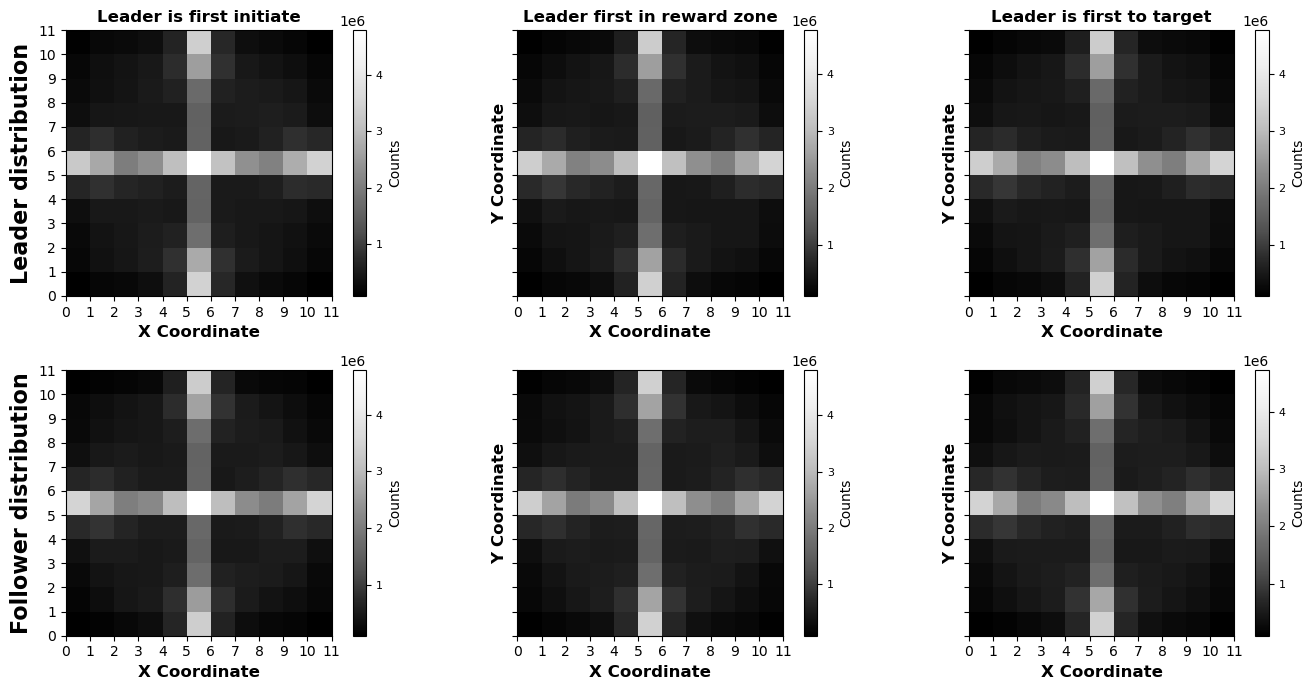

In [ ]:
fig, axsed = plt.subplots(2, 3, figsize=(14, 7), sharey=True, dpi=100)

axs = axsed[:, :]
ax = axs[0, :]
# Calculate and plot the density for each strategy
xi1, yi1, zi1 = get_density_heatmap(l1x.flatten(), l1y.flatten())
plot_heatmap(ax[0], xi1, yi1, zi1, 'Leader is first initiate')
xi2, yi2, zi2 = get_density_heatmap(l2x.flatten(), l2y.flatten())
plot_heatmap(ax[1], xi2, yi2, zi2, 'Leader first in reward zone')
xi3, yi3, zi3 = get_density_heatmap(l3x.flatten(), l3y.flatten())
plot_heatmap(ax[2], xi3, yi3, zi3, 'Leader is first to target')
# plt.suptitle('Evaluation - Density of Leader Positions', fontsize=14, fontweight='bold')

ax = axs[1, :]
# Calculate and plot the density for each strategy
xi1, yi1, zi1 = get_density_heatmap(f1x.flatten(), f1y.flatten())
plot_heatmap(ax[0], xi1, yi1, zi1, '')
xi2, yi2, zi2 = get_density_heatmap(f2x.flatten(), f2y.flatten())
plot_heatmap(ax[1], xi2, yi2, zi2, '')
xi3, yi3, zi3 = get_density_heatmap(f3x.flatten(), f3y.flatten())
plot_heatmap(ax[2], xi3, yi3, zi3, '')
# plt.suptitle('Evaluation - Density of Follower Positions', fontsize=14, fontweight='bold')

axs[0,0].set_ylabel('Leader distribution', fontsize=16, fontweight='bold')
axs[1,0].set_ylabel('Follower distribution', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

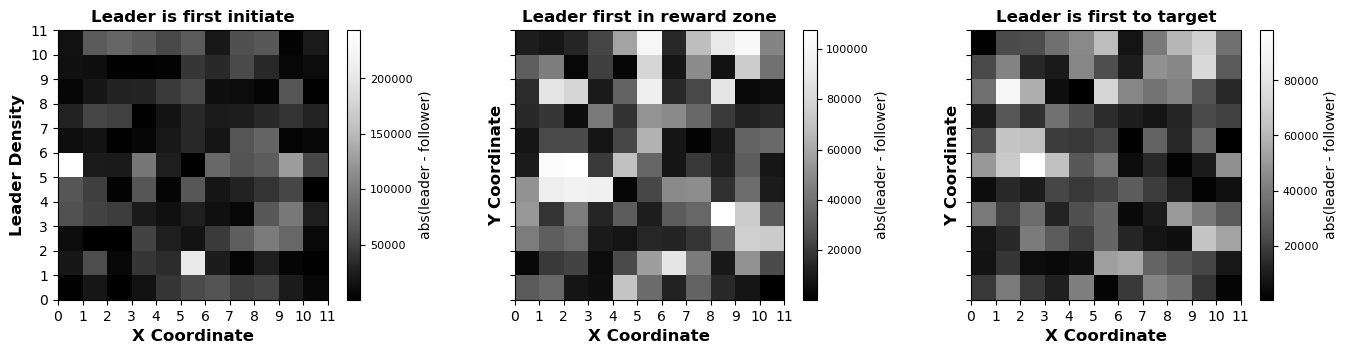

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14, 7/2), sharey=True, dpi=100)

# Calculate and plot the density for each strategy
xi1l, yi1l, zi1l = get_density_heatmap(l1x.flatten(), l1y.flatten())
xi1, yi1, zi1 = get_density_heatmap(f1x.flatten(), f1y.flatten())
plot_heatmap(ax[0], xi1, yi1, np.abs(zi1l-zi1), 'Leader is first initiate', 'abs(leader - follower)')
xi2l, yi2l, zi2l = get_density_heatmap(l2x.flatten(), l2y.flatten())
xi2, yi2, zi2 = get_density_heatmap(f2x.flatten(), f2y.flatten())
plot_heatmap(ax[1], xi2, yi2, np.abs(zi2l-zi2), 'Leader first in reward zone', 'abs(leader - follower)')
xi3l, yi3l, zi3l = get_density_heatmap(l3x.flatten(), l3y.flatten())
xi3, yi3, zi3 = get_density_heatmap(f3x.flatten(), f3y.flatten())
plot_heatmap(ax[2], xi3, yi3, np.abs(zi3l-zi3), 'Leader is first to target', 'abs(leader - follower)')
# plt.suptitle('Evaluation - Density of Leader Positions', fontsize=14, fontweight='bold')

ax[0].set_ylabel('Leader Density', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

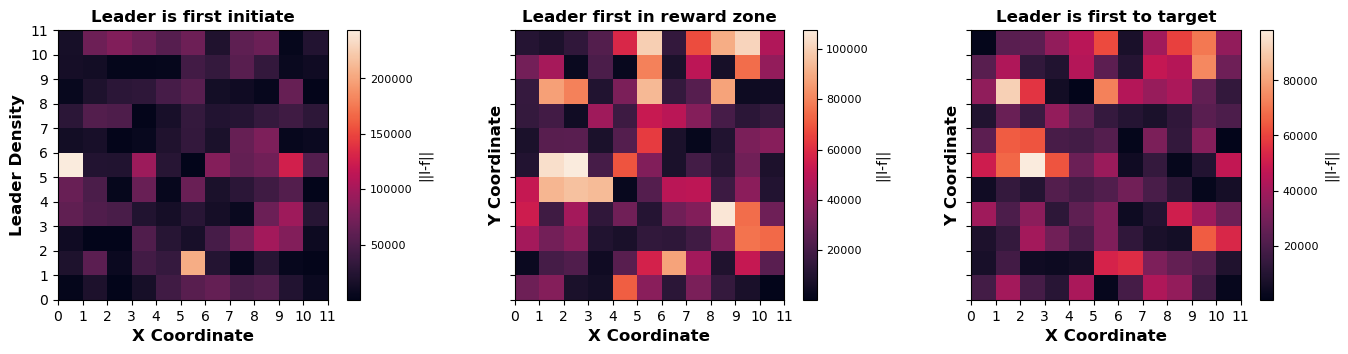

In [66]:
fig, ax = plt.subplots(1, 3, figsize=(14, 7/2), sharey=True, dpi=100)

# Calculate and plot the density for each strategy
xi1l, yi1l, zi1l = get_density_heatmap(l1x.flatten(), l1y.flatten())
xi1, yi1, zi1 = get_density_heatmap(f1x.flatten(), f1y.flatten())
plot_heatmap(ax[0], xi1, yi1, np.abs(zi1l-zi1), 'Leader is first initiate', 'abs(leader - follower)')
xi2l, yi2l, zi2l = get_density_heatmap(l2x.flatten(), l2y.flatten())
xi2, yi2, zi2 = get_density_heatmap(f2x.flatten(), f2y.flatten())
plot_heatmap(ax[1], xi2, yi2, np.abs(zi2l-zi2), 'Leader first in reward zone', 'abs(leader - follower)')
xi3l, yi3l, zi3l = get_density_heatmap(l3x.flatten(), l3y.flatten())
xi3, yi3, zi3 = get_density_heatmap(f3x.flatten(), f3y.flatten())
plot_heatmap(ax[2], xi3, yi3, np.abs(zi3l-zi3), 'Leader is first to target', 'abs(leader - follower)')
# plt.suptitle('Evaluation - Density of Leader Positions', fontsize=14, fontweight='bold')

ax[0].set_ylabel('Leader Density', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()